# INTRODUCTION TO MACHINE LEARNING WITH PYTHON #

## INTROUDCTION ##

Machine learning is about extracting knowledge from data. It is a research field at the intersection of statistics, artificial intelligence, 
and computer science and is also known as predictive analytics or statistical learning.

In [1]:
!pip install mglearn


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
print("System version: {}".format(sys.version))

import numpy as np
print("Numpy version is: {}".format(np.__version__))

import matplotlib
import matplotlib.pyplot as plt
print("Matplotlib version: {}".format(matplotlib.__version__))

import pandas as pd
print("Pandas version : {}".format(pd.__version__))

import scipy
print("Scipy version:{}".format(scipy.__version__))

import IPython 
print("IPython version: {}".format(IPython.__version__))

import sklearn
print("Sklearn version: {}".format(sklearn.__version__))


System version: 3.10.2 (tags/v3.10.2:a58ebcc, Jan 17 2022, 14:12:15) [MSC v.1929 64 bit (AMD64)]
Numpy version is: 2.0.2
Matplotlib version: 3.9.2
Pandas version : 2.2.3
Scipy version:1.14.1
IPython version: 8.29.0
Sklearn version: 1.6.0


### IRIS CLASSIFICATION ###

In [3]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

In [4]:
print('Here are the different iris keys: {}'.format(iris_dataset.keys()))

Here are the different iris keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [5]:
#Short description of the dataset
print(iris_dataset.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [6]:
print(iris_dataset.target_names)

['setosa' 'versicolor' 'virginica']


In [7]:
print('Features: {}'.format(iris_dataset.feature_names))

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [8]:
print("Iris dataset shape: {}".format(iris_dataset.data.shape))

Iris dataset shape: (150, 4)


In [9]:
print('Target: {}'.format(iris_dataset.target))
#Each specy is encoded as an integer from 0 to 2: 0-setsoa, 1-versicolor, 2-virginica

Target: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [10]:
# Splitting datas
from  sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_dataset.data, iris_dataset.target, random_state=0)

#Train dataset
print("X_train shape: {}".format(X_train.shape))
print("y_train shape: {}".format(y_train.shape))

#Test dataset
print("X_test shape: {}".format(X_test.shape))
print("y_test shape: {}".format(y_test.shape))

X_train shape: (112, 4)
y_train shape: (112,)
X_test shape: (38, 4)
y_test shape: (38,)


### First Things First: Look at Your Data
Before building a machine learning model it is often a good idea to inspect the data,
to see if the task is easily solvable without machine learning, or if the desired infor‐
mation might not be contained in the data.
Additionally, inspecting your data is a good way to find abnormalities and peculiarities. Maybe some of your irises were measured using inches and not centimeters, for
example. In the real world, inconsistencies in the data and unexpected measurements
are very common.

### Visualising your data
One of the best ways to inspect data is to visualize it. One way to do this is by using a
scatter plot. A scatter plot of the data puts one feature along the x-axis and another
along the y-axis, and draws a dot for each data point. Unfortunately, computer
screens have only two dimensions, which allows us to plot only two (or maybe three)
features at a time. It is difficult to plot datasets with more than three features this way.
One way around this problem is to do a pair plot, which looks at all possible pairs of
features. If you have a small number of features, such as the four we have here, this is
quite reasonable. You should keep in mind, however, that a pair plot does not show
the interaction of all of features at once, so some interesting aspects of the data may
not be revealed when visualizing it this wa

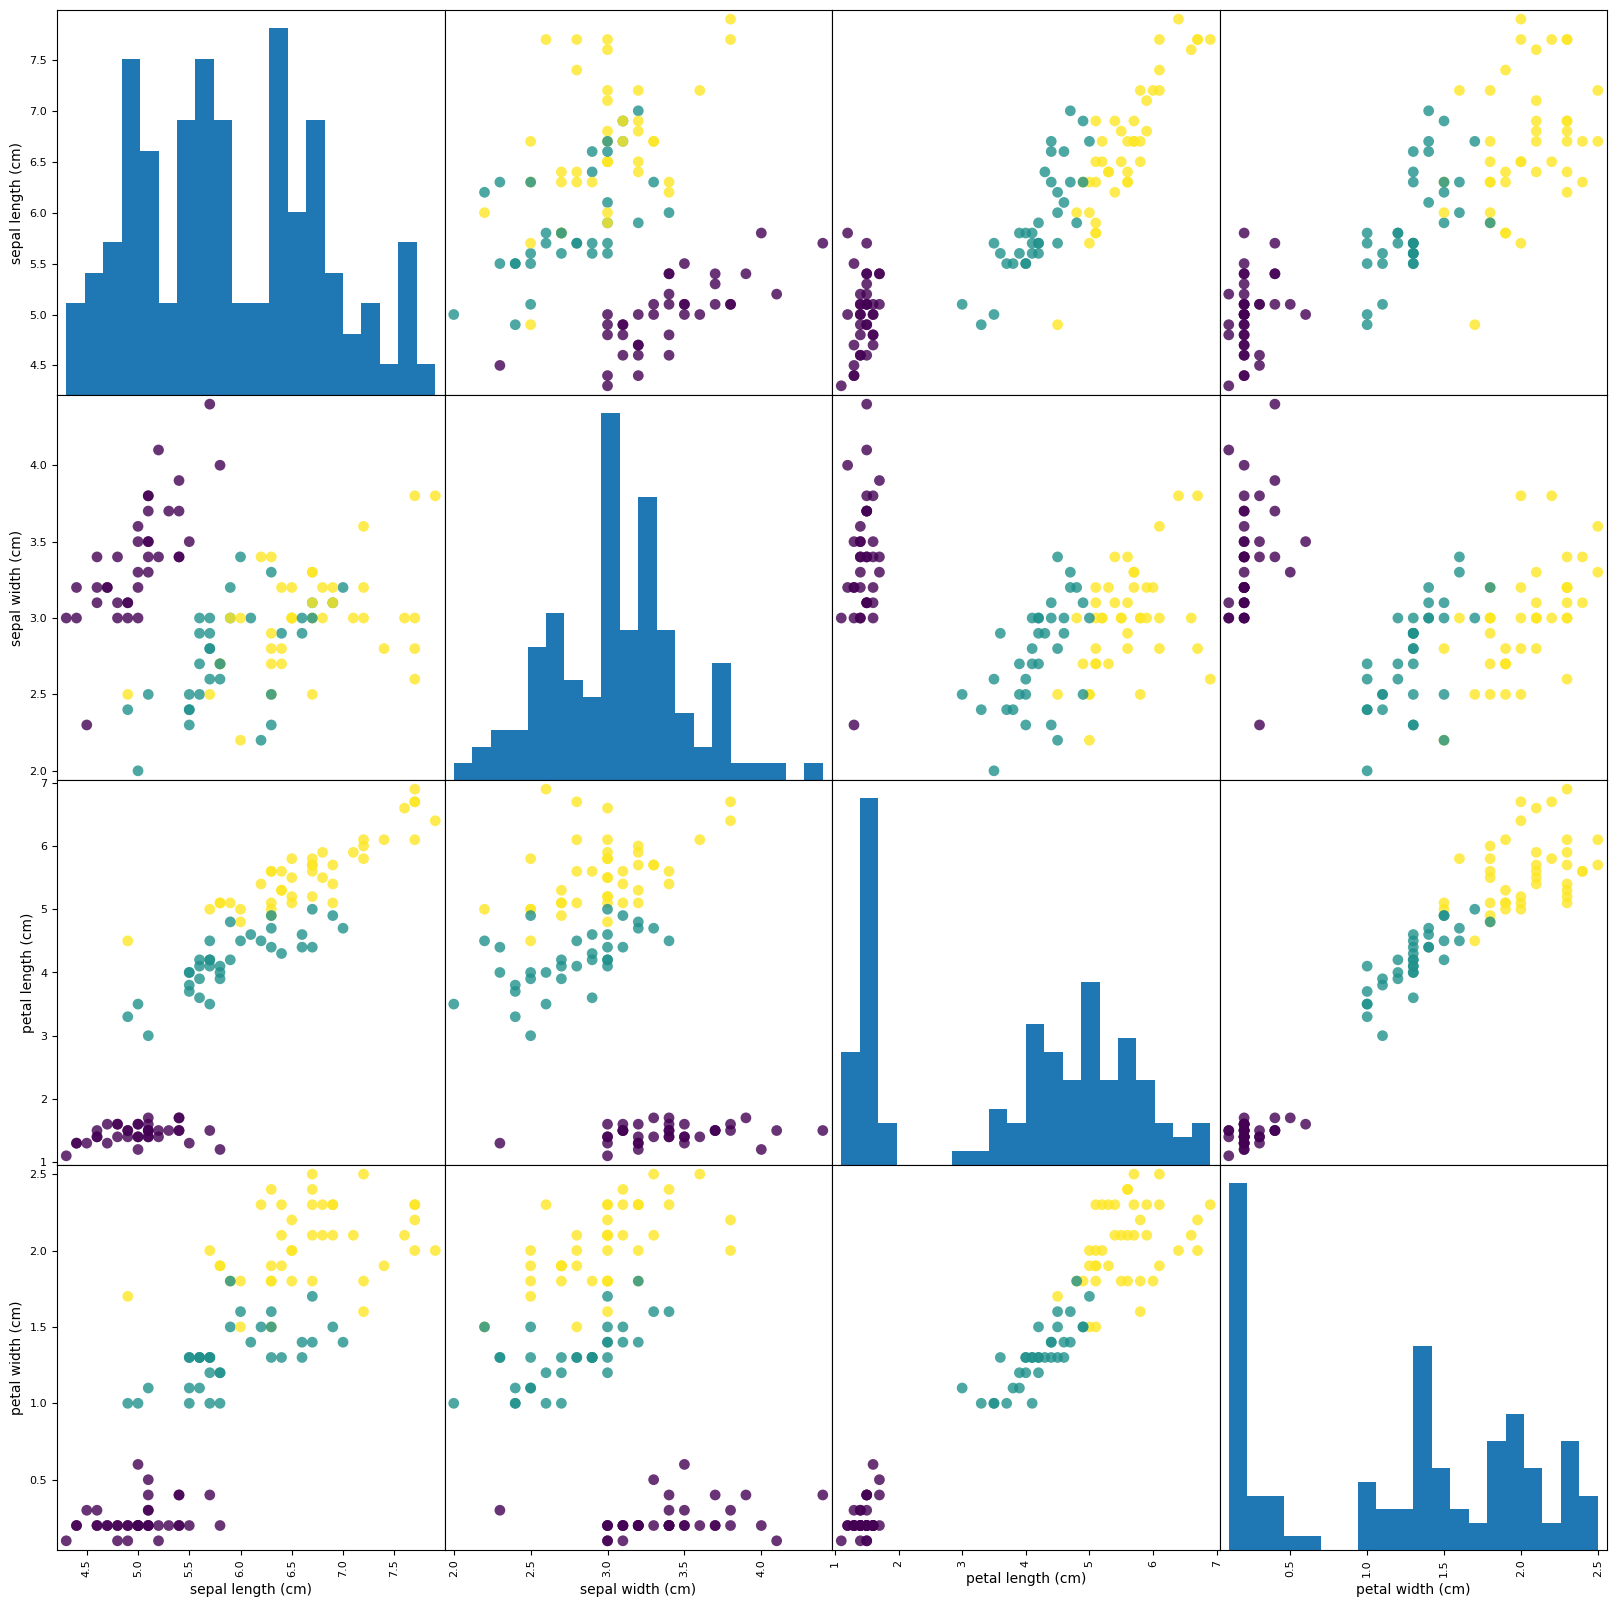

In [11]:
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.feature_names)

grr = pd.plotting.scatter_matrix(iris_dataframe, c=y_train, figsize=(20, 20), marker='o', hist_kwds={'bins':20}, s=60, alpha=.8)

### BUILD THE FIRST MODEL: K-NEAREST NEIGHBOR

In [12]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [13]:
#Example
X_new = np.array([[5, 2.9, 1, 0.2]])
print("X_new.shape: {}".format(X_new.shape))

predictions = knn.predict(X_new)
print("Predicted target name: {}".format(iris_dataset.target_names[predictions]))

X_new.shape: (1, 4)
Predicted target name: ['setosa']


In [14]:
y_pred = knn.predict(X_test)
print("Predictions of the test dataset: {}".format(y_pred))

print("Test score: {:.2f}".format(np.mean(y_pred==y_test)))
print("Another method to evaluate the model by using its test score: {:.2f}".format(knn.score(X_test, y_test)))

Predictions of the test dataset: [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]
Test score: 0.97
Another method to evaluate the model by using its test score: 0.97


## SUPERVISED LEARNING

### Classification and Regression

In classification, the goal is to predict a class label, which is a choice from a predefined
list of possibilities. There is also exists binary classification where the goal is to clasiify into 2 classes, or to give the answer
of a yes/no question.
Regression refers to the prediction of a continuous number 

### Generalization, Overfitting, and Underfitting

Building a model that is too complex for the amount of information we have is called overfitting. 
Overfitting occurs when you fit a model too closely to the particularities of the training set and obtain a model that works well on the training set but is not able to generalize to new data. 
The more complex we allow our model to be, the better we will be able to predict on the training data. However, if our model becomes too complex, we start focusing too much on each individual data point in our training set, and the model will not generalize well to new data.

### BREAST CANCER CLASSIFICATION

In [15]:
from  sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
print("Cancer keys: {}".format(cancer.keys()))

Cancer keys: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [16]:
print("Cancer dataset shape: {}".format(cancer.data.shape))

Cancer dataset shape: (569, 30)


In [17]:
#Occurences in each class
print("Samples per class: {}".format({n: v for n, v in zip(cancer.target_names, np.bincount(cancer.target))}))

Samples per class: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


In [18]:
print("Feature names: {}".format(cancer.feature_names))

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


### CALIFORNIA HOUSING PRICE

In [19]:
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()
print("California data shape: {}".format(california.data.shape))

California data shape: (20640, 8)


### k-Nearest Neighbors
The k-NN algorithm is arguably the simplest machine learning algorithm. Building the model consists only of storing the training dataset. To make a prediction for a new data point, the algorithm finds the closest data points in the training dataset—its “nearest neighbors.

In [20]:
clf = KNeighborsClassifier(n_neighbors=3)
X_train, X_test, y_train, y_test  = train_test_split(cancer.data, cancer.target, random_state=0)

clf.fit(X_train, y_train)
print("Test predictions: {}".format(clf.predict(X_test)))
print("Test set accuracy: {}".format(np.mean(clf.predict(X_test)==y_test)))
print("Test set accuracy: {}".format(clf.score(X_test, y_test)))

Test predictions: [0 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 0 0 0 0 1 1 0 1 1 1 1 0 1 0 1 0 1 0 1
 0 1 0 0 1 0 1 0 0 1 1 1 0 0 1 0 1 1 1 1 1 1 0 0 0 1 1 0 1 0 0 0 1 1 0 1 1
 0 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 1
 0 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 1 1 1 0]
Test set accuracy: 0.9230769230769231
Test set accuracy: 0.9230769230769231


A smoother boundary corresponds to a simpler model. In other words, using few neighbors corresponds to high model complexity, and using many neighbors corresponds to low model complexity (as shown on the left side of Figure 2-1). If you consider the extreme case where the number of neighbors is the number of all data points in the training set, each test point would have exactly the same neighbors (all training points) and all predictions would be the same: the class that is most frequent in the training set.

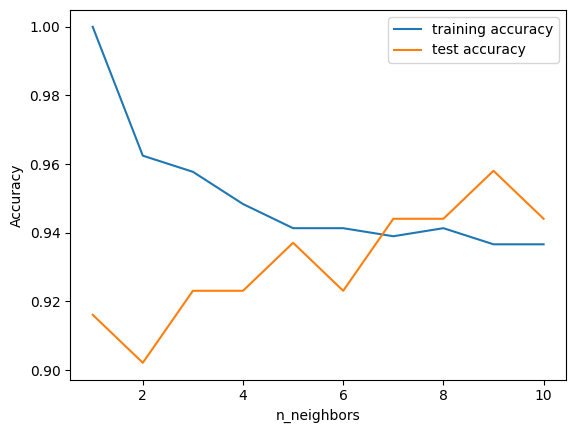

In [21]:
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 10
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_train, y_train)
    # record training set accuracy
    training_accuracy.append(clf.score(X_train, y_train))
    # record generalization accuracy
    test_accuracy.append(clf.score(X_test, y_test))
    
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

There is also a regression variant of the k-nearest neighbors algorithm. Again, let’s start by using the single nearest neighbor, this time using the wave dataset. We’ve added three test data points as green stars on the x-axis. The prediction using a single neighbor is just the target value of the nearest neighbor. When using multiple nearest neighbors, the prediction is the average, or mean, of the relevant neighbors.
We can also evaluate the model using the score method, which for regressors returns the R^2 score. The R^2 score, also known as the coefficient of determination, is a measure of goodness of a prediction for a regression model, and yields a score between 0 and 1.

### Strengths, weaknesses, and parameters


In principle, there are two important parameters to the KNeighbors classifier: the
number of neighbors and how you measure distance between data points. In practice,
using a small number of neighbors like three or five often works well, but you should
certainly adjust this parameter.
By default, Euclidean distance is used, which works
well in many settings.

One of the strengths of k-NN is that the model is very easy to understand, and often
gives reasonable performance without a lot of adjustments. Using this algorithm is a
good baseline method to try before considering more advanced techniques. Building
the nearest neighbors model is usually very fast, but when your training set is very
large (either in number of features or in number of samples) prediction can be slow.
When using the k-NN algorithm, it’s important to preprocess your data. This approach often does not perform well on datasets with many features
(hundreds or more), and it does particularly badly with datasets where most features
are 0 most of the time (so-called sparse datasets).




### Linear Models

Linear models are a class of models that are widely used in practice and have been
studied extensively in the last few decades, with roots going back over a hundred
years. Linear models make a prediction using a linear function of the input features,
which we will explain shortly.

In [22]:
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test  = train_test_split(california.data, california.target, random_state=0)

lr = LinearRegression().fit(X_train, y_train)

In [23]:
# The “slope” parameters (w), also called weights or coefficients, are stored in the coef_
#attribute, while the offset or intercept (b) in  the intercept_ attribute

print("Linear coef: {}".format(lr.coef_))
print("Linear intercet: {}".format(lr.intercept_))

Linear coef: [ 4.39091042e-01  9.59864665e-03 -1.03311173e-01  6.16730152e-01
 -7.63275197e-06 -4.48838256e-03 -4.17353284e-01 -4.30614462e-01]
Linear intercet: -36.60959377871418


In [24]:
print("Training set score: {:.2f}".format(lr.score(X_train, y_train)))
print("Test set score: {:.2f}".format(lr.score(X_test, y_test)))

Training set score: 0.61
Test set score: 0.59


This means we are likely underfitting, not over‐
fitting. For this one-dimensional dataset, there is little danger of overfitting, as the
model is very simple (or restricted). However, with higher-dimensional datasets
(meaning datasets with a large number of features), linear models become more pow‐
erful, and there is a higher chance of overfitting. 
When there is a disruprancy between the training set score and the test set score we are likely overfitting.

### Ridge regression

Ridge regression is also a linear model for regression, so the formula it uses to make
predictions is the same one used for ordinary least squares. In ridge regression,
though, the coefficients (w) are chosen not only so that they predict well on the train‐
ing data, but also to fit an additional constraint. We also want the magnitude of coef‐
ficients to be as small as possible; in other words, all entries of w should be close to
zero. Intuitively, this means each feature should have as little effect on the outcome as
possible (which translates to having a small slope), while still predicting well. This
constraint is an example of what is called regularization. Regularization means explic‐
itly restricting a model to avoid overfitting.

In [25]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10).fit(X_train, y_train)

print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))

Training set score: 0.61
Test set score: 0.59


As one would expect, the training score is higher than the test score for all dataset
sizes, for both ridge and linear regression. Because ridge is regularized, the training
score of ridge is lower than the training score for linear regression across the board.
However, the test score for ridge is better, particularly for small subsets of the data.
For less than 400 data points, linear regression is not able to learn anything. As more
and more data becomes available to the model, both models improve, and linear
regression catches up with ridge in the end. The lesson here is that with enough train‐
ing data, regularization becomes less important, and given enough data, ridge and linear regression will have the same performance (the fact that this happens here
when using the full dataset is just by chance). 

### Lasso

As with ridge
regression, using the lasso also restricts coefficients to be close to zero, but in a
slightly different way, called L1 regularization.8 The consequence of L1 regularization
is that when using the lasso, some coefficients are exactly zero. This means some fea‐
tures are entirely ignored by the model. This can be seen as a form of automatic fea‐
ture selection. 

In [26]:
from sklearn.linear_model import Lasso

lasso = Lasso().fit(X_train, y_train)
print('Lasso train score: {:.2f}'.format(lasso.score(X_train, y_train)))
print('Lasso test score: {:.2f}'.format(lasso.score(X_test, y_test)))
print('NUmber of features used: {}'.format(np.sum(lasso.coef_!=0)))

Lasso train score: 0.29
Lasso test score: 0.28
NUmber of features used: 3


In [27]:
lasso2 = Lasso(alpha=0.001, max_iter=100000).fit(X_train, y_train)
print('Lasso train score: {:.2f}'.format(lasso2.score(X_train, y_train)))
print('Lasso test score: {:.2f}'.format(lasso2.score(X_test, y_test)))
print('NUmber of features used: {}'.format(np.sum(lasso2.coef_!=0)))

Lasso train score: 0.61
Lasso test score: 0.59
NUmber of features used: 8


A lower alpha allowed us to fit a more complex model, which worked better on the
training and test data

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, stratify = cancer.target, random_state=42)
logreg = LogisticRegression().fit(X_train, y_train)
print('Train score: {:.3f}'.format(logreg.score(X_train, y_train)))
print('Test score: {:.3f}'.format(logreg.score(X_test, y_test)))

Train score: 0.955
Test score: 0.951


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
logreg2 = LogisticRegression().fit(X_train, y_train)
print('Train score: {:.3f}'.format(logreg2.score(X_train, y_train)))
print('Test score: {:.3f}'.format(logreg2.score(X_test, y_test)))

Train score: 0.955
Test score: 0.951


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The main parameter of linear models is the regularization parameter, called alpha in
the regression models and C in LinearSVC and LogisticRegression. Large values for
alpha or small values for C mean simple models. In particular for the regression mod‐
els, tuning these parameters is quite important. Usually C and alpha are searched for
on a logarithmic scale. The other decision you have to make is whether you want to
use L1 regularization or L2 regularization. If you assume that only a few of your fea‐
tures are actually important, you should use L1. Otherwise, you should default to L2.
L1 can also be useful if interpretability of the model is important. As L1 will use only
a few features, it is easier to explain which features are important to the model, and
what the effects of these features are.

Linear models are very fast to train, and also fast to predict. They scale to very large
datasets and work well with sparse data. If your data consists of hundreds of thou‐
sands or millions of samples, you might want to investigate using the solver='sag'
option in LogisticRegression and Ridge, which can be faster than the default on
large datasets. Other options are the SGDClassifier class and the SGDRegressor
class, which implement even more scalable versions of the linear models described
here.

Another strength of linear models is that they make it relatively easy to understand
how a prediction is made, using the formulas we saw earlier for regression and classi‐
fication. Unfortunately, it is often not entirely clear why coefficients are the way they
are. This is particularly true if your dataset has highly correlated features; in these
cases, the coefficients might be hard to interpret.
Linear models often perform well when the number of features is large compared to
the number of samples. They are also often used on very large datasets, simply
because it’s not feasible to train other models. However, in lower-dimensional spaces,
other models might yield better generalization performance. 

### Method Chaining
The fit method of all scikit-learn models returns self. This allows you to write
code like the following, which we’ve already used extensively in this chapter:

#### instantiate model and fit it in one line
logreg = LogisticRegression().fit(X_train, y_train)
Here, we used the return value of fit (which is self) to assign the trained model to
the variable logreg. This concatenation of method calls (here __init__ and then fit)
is known as method chaining. Another common application of method chaining in
scikit-learn is to fit and predict in one line:
#### Example
logreg = LogisticRegression()
y_pred = logreg.fit(X_train, y_train).predict(X_test)
Finally, you can even do model instantiation, fitting, and predicting in one line:
#### Example
y_pred = LogisticRegression().fit(X_train, y_train).predict(X_test)
This very short variant is not ideal, though. A lot is happening in a single line, which
might make the code hard to read. Additionally, the fitted logistic regression model
isn’t stored in any variable, so we can’t inspect it or use it to predict on any other data

### Naive Bayes Classifiers

Naive Bayes classifiers are a family of classifiers that are quite similar to the linear
models discussed in the previous section. However, they tend to be even faster in
training. The price paid for this efficiency is that naive Bayes models often provide
generalization performance that is slightly worse than that of linear classifiers like
LogisticRegression and LinearSVC.

The reason that naive Bayes models are so efficient is that they learn parameters by
looking at each feature individually and collect simple per-class statistics from each
feature. There are three kinds of naive Bayes classifiers implemented in scikit-learn: GaussianNB, BernoulliNB, and MultinomialNB. GaussianNB can be applied to
any continuous data, while BernoulliNB assumes binary data and MultinomialNB
assumes count data (that is, that each feature represents an integer count of some‐
thing, like how often a word appears in a sentence). BernoulliNB and MultinomialNB
are mostly used in text data classification.
MultinomialNB and BernoulliNB have a single parameter, alpha, which controls
model complexity. The way alpha works is that the algorithm adds to the data alpha
many virtual data points that have positive values for all the features. This results in a
“smoothing” of the statistics. A large alpha means more smoothing, resulting in less
complex models. The algorithm’s performance is relatively robust to the setting of
alpha, meaning that setting alpha is not critical for good performance. However,
tuning it usually improves accuracy somewhat.

GaussianNB is mostly used on very high-dimensional data, while the other two var‐
iants of naive Bayes are widely used for sparse count data such as text. MultinomialNB
usually performs better than BinaryNB, particularly on datasets with a relatively large
number of nonzero features (i.e., large documents).

The naive Bayes models share many of the strengths and weaknesses of the linear
models. They are very fast to train and to predict, and the training procedure is easy
to understand. The models work very well with high-dimensional sparse data and are
relatively robust to the parameters. Naive Bayes models are great baseline models and
are often used on very large datasets, where training even a linear model might take
too long.

### Decision Trees
Decision trees are widely used models for classification and regression tasks. Essen‐
tially, they learn a hierarchy of if/else questions, leading to a decision.
These questions are similar to the questions you might ask in a game of 20 Questions.
Imagine you want to distinguish between the following four animals: bears, hawks,
penguins, and dolphins. Your goal is to get to the right answer by asking as few if/else
questions as possible. You might start off by asking whether the animal has feathers, a
question that narrows down your possible animals to just two. If the answer is “yes,”
you can ask another question that could help you distinguish between hawks and
penguins. For example, you could ask whether the animal can fly. If the animal
doesn’t have feathers, your possible animal choices are dolphins and bears, and you
will need to ask a question to distinguish between these two animals—for example,
asking whether the animal has fins.


In [30]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print('Train score: {:.3f}'.format(tree.score(X_train, y_train)))
print('Test score: {:.3f}'.format(tree.score(X_test, y_test)))

Train score: 1.000
Test score: 0.937


If we don’t restrict the depth of a decision tree, the tree can become arbitrarily deep
and complex. Unpruned trees are therefore prone to overfitting and not generalizing
well to new data.

In [31]:
tree = DecisionTreeClassifier(max_depth=4, random_state=0)
tree.fit(X_train, y_train)
print('Train score: {:.3f}'.format(tree.score(X_train, y_train)))
print('Test score: {:.3f}'.format(tree.score(X_test, y_test)))

Train score: 0.988
Test score: 0.951


In [32]:
from sklearn.tree import export_graphviz
export_graphviz(tree, out_file='tree.dot', class_names=["malignant", "benign"], 
                feature_names=cancer.feature_names, impurity=False, filled=True)


In [33]:
print('Tree features importance: {}'.format(tree.feature_importances_))

Tree features importance: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.01019737 0.04839825
 0.         0.         0.0024156  0.         0.         0.
 0.         0.         0.72682851 0.0458159  0.         0.
 0.0141577  0.         0.018188   0.1221132  0.01188548 0.        ]


Strengths, weaknesses, and parameters
As discussed earlier, the parameters that control model complexity in decision trees
are the pre-pruning parameters that stop the building of the tree before it is fully
developed. Usually, picking one of the pre-pruning strategies—setting either max_depth, max_leaf_nodes, or min_samples_leaf—is sufficient to prevent overfitting.

Decision trees have two advantages over many of the algorithms we’ve discussed so
far: the resulting model can easily be visualized and understood by nonexperts (at
least for smaller trees), and the algorithms are completely invariant to scaling of the
data. As each feature is processed separately, and the possible splits of the data don’t
depend on scaling, no preprocessing like normalization or standardization of features
is needed for decision tree algorithms. In particular, decision trees work well when
you have features that are on completely different scales, or a mix of binary and continuous features.

The main downside of decision trees is that even with the use of pre-pruning, they
tend to overfit and provide poor generalization performance. Therefore, in most
applications, the ensemble methods we discuss next are usually used in place of a sin‐
gle decision tree.

### Ensembles of Decision Trees
Ensembles are methods that combine multiple machine learning models to create
more powerful models. There are many models in the machine learning literature
that belong to this category, but there are two ensemble models that have proven to
be effective on a wide range of datasets for classification and regression, both of
which use decision trees as their building blocks: random forests and gradient boosted decision trees.

#### Random forests
As we just observed, a main drawback of decision trees is that they tend to overfit the
training data. Random forests are one way to address this problem. A random forest
is essentially a collection of decision trees, where each tree is slightly different from
the others. The idea behind random forests is that each tree might do a relatively
good job of predicting, but will likely overfit on part of the data. If we build many
trees, all of which work well and overfit in different ways, we can reduce the amount
of overfitting by averaging their results. This reduction in overfitting, while retaining
the predictive power of the trees, can be shown using rigorous mathematics.




In [34]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=100, random_state=0).fit(X_train, y_train)
print('Train score: {:.3f}'.format(forest.score(X_train, y_train)))
print('Test score: {:.3f}'.format(forest.score(X_test, y_test)))

Train score: 1.000
Test score: 0.958


### Strengths, weaknesses, and parameters. 
Random forests for regression and classification are currently among the most widely used machine learning methods. They are
very powerful, often work well without heavy tuning of the parameters, and don’t
require scaling of the data.
Essentially, random forests share all of the benefits of decision trees, while making up
for some of their deficiencies. One reason to still use decision trees is if you need a
compact representation of the decision-making process. It is basically impossible to
interpret tens or hundreds of trees in detail, and trees in random forests tend to be
deeper than decision trees (because of the use of feature subsets). Therefore, if you
need to summarize the prediction making in a visual way to nonexperts, a single
decision tree might be a better choice. While building random forests on large data‐
sets might be somewhat time consuming, it can be parallelized across multiple CPU- cores within a computer easily. If you are using a multi-core processor (as nearly all
modern computers do), you can use the n_jobs parameter to adjust the number of
cores to use. Using more CPU cores will result in linear speed-ups (using two cores,
the training of the random forest will be twice as fast), but specifying n_jobs larger
than the number of cores will not help. You can set n_jobs=-1 to use all the cores in
your computer.
You should keep in mind that random forests, by their nature, are random, and set‐
ting different random states (or not setting the random_state at all) can drastically
change the model that is built. The more trees there are in the forest, the more robust
it will be against the choice of random state. If you want to have reproducible results,
it is important to fix the random_state.
Random forests don’t tend to perform well on very high dimensional, sparse data,
such as text data. For this kind of data, linear models might be more appropriate.
Random forests usually work well even on very large datasets, and training can easily
be parallelized over many CPU cores within a powerful computer. However, random
forests require more memory and are slower to train and to predict than linear mod‐
els. If time and memory are important in an application, it might make sense to use a
linear model instead.
The important parameters to adjust are n_estimators, max_features, and possibly
pre-pruning options like max_depth. For n_estimators, larger is always better. Aver‐
aging more trees will yield a more robust ensemble by reducing overfitting. However,
there are diminishing returns, and more trees need more memory and more time to
train. A common rule of thumb is to build “as many as you have time/memory for.”
As described earlier, max_features determines how random each tree is, and a
smaller max_features reduces overfitting. In general, it’s a good rule of thumb to use
the default values: max_features=sqrt(n_features) for classification and max_fea
tures=log2(n_features) for regression. Adding max_features or max_leaf_nodes
might sometimes improve performance. It can also drastically reduce space and time
requirements for training and prediction.

### Gradient Boosted Regression Trees
The main idea behind gradient boosting is to combine many simple models (in this
context known as weak learners), like shallow trees. Each tree can only provide good
predictions on part of the data, and so more and more trees are added to iteratively
improve performance.
Gradient boosted trees are frequently the winning entries in machine learning com‐
petitions, and are widely used in industry. They are generally a bit more sensitive to
parameter settings than random forests, but can provide better accuracy if the param‐
eters are set correctly.
Apart from the pre-pruning and the number of trees in the ensemble, another impor‐
tant parameter of gradient boosting is the learning_rate, which controls how
strongly each tree tries to correct the mistakes of the previous trees. A higher learning
rate means each tree can make stronger corrections, allowing for more complex mod‐
els. Adding more trees to the ensemble, which can be accomplished by increasing
n_estimators, also increases the model complexity, as the model has more chances
to correct mistakes on the training set.


In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.958


In [36]:
gbrt = GradientBoostingClassifier(random_state=0, max_depth=1)
gbrt.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.958


In [37]:
gbrt = GradientBoostingClassifier(random_state=0, learning_rate=0.01)
gbrt.fit(X_train, y_train)

print("Accuracy on training set: {:.3f}".format(gbrt.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(gbrt.score(X_test, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.937


Both methods of decreasing the model complexity reduced the training set accuracy,
as expected. In this case, lowering the maximum depth of the trees provided a signifi‐
cant improvement of the model, while lowering the learning rate only increased the
generalization performance slightly.

#### Strengths, weaknesses, and parameters.
Gradient boosted decision trees are among the
most powerful and widely used models for supervised learning. Their main drawback
is that they require careful tuning of the parameters and may take a long time to
train. Similarly to other tree-based models, the algorithm works well without scaling
and on a mixture of binary and continuous features. As with other tree-based models,
it also often does not work well on high-dimensional sparse data.
The main parameters of gradient boosted tree models are the number of trees, n_esti
mators, and the learning_rate, which controls the degree to which each tree is
allowed to correct the mistakes of the previous trees. These two parameters are highly interconnected, as a lower learning_rate means that more trees are needed to build
a model of similar complexity. In contrast to random forests, where a higher n_esti
mators value is always better, increasing n_estimators in gradient boosting leads to a
more complex model, which may lead to overfitting. A common practice is to fit
n_estimators depending on the time and memory budget, and then search over dif‐
ferent learning_rates.
Another important parameter is max_depth (or alternatively max_leaf_nodes), to
reduce the complexity of each tree. Usually max_depth is set very low for gradient
boosted models, often not deeper than five splits.

### Kernelized Support Vector Machines

Kernelized support vector machines
(often just referred to as SVMs) are an extension that allows for more complex mod‐
els that are not defined simply by hyperplanes in the input space. While there are sup‐
port vector machines for classification and regression, we will restrict ourselves to the
classification case, as implemented in SVC. Similar concepts apply to support vector
regression, as implemented in SVR.


#### The kernel trick
The lesson here is that adding nonlinear features to the representation of our data can
make linear models much more powerful. However, often we don’t know which fea‐
tures to add, and adding many features (like all possible interactions in a 100-
dimensional feature space) might make computation very expensive. Luckily, there is
a clever mathematical trick that allows us to learn a classifier in a higher-dimensional
space without actually computing the new, possibly very large representation. This is
known as the kernel trick, and it works by directly computing the distance (more pre‐
cisely, the scalar products) of the data points for the expanded feature representation,
without ever actually computing the expansion.
There are two ways to map your data into a higher-dimensional space that are com‐
monly used with support vector machines: the polynomial kernel, which computes all
possible polynomials up to a certain degree of the original features (like feature1 **
2 * feature2 ** 5); and the radial basis function (RBF) kernel, also known as the
Gaussian kernel. The Gaussian kernel is a bit harder to explain, as it corresponds to
an infinite-dimensional feature space. One way to explain the Gaussian kernel is that it considers all possible polynomials of all degrees, but the importance of the features
decreases for higher degrees.

#### Understanding SVMs

During training, the SVM learns how important each of the training data points is to
represent the decision boundary between the two classes. Typically only a subset of
the training points matter for defining the decision boundary: the ones that lie on the
border between the classes. These are called support vectors and give the support vec‐
tor machine its name.
To make a prediction for a new point, the distance to each of the support vectors is
measured. A classification decision is made based on the distances to the support vec‐
tor, and the importance of the support vectors that was learned during training
(stored in the dual_coef_ attribute of SVC).
The distance between data points is measured by the Gaussian kernel:
krbf(x1, x2) = exp (ɣǁx1 - x2ǁ2)
Here, x1 and x2 are data points, ǁ x1 - x2 ǁ denotes Euclidean distance, and ɣ (gamma)
is a parameter that controls the width of the Gaussian kernel.

#### Tuning SVM parameters

The gamma parameter is the one shown in the formula given in the previous section,
which controls the width of the Gaussian kernel. It determines the scale of what it
means for points to be close together. The C parameter is a regularization parameter,
similar to that used in the linear models. It limits the importance of each point (or
more precisely, their dual_coef_).

In [38]:
from sklearn.svm import SVC

svc = SVC()
svc.fit(X_train, y_train)

print('Accuracy training set: {:.3f}'.format(svc.score(X_train, y_train)))
print('Accuracy test set: {:.3f}'.format(svc.score(X_test, y_test)))


Accuracy training set: 0.918
Accuracy test set: 0.923


In [39]:
svc = SVC(C=1000)
svc.fit(X_train, y_train)

print('Accuracy training set: {:.3f}'.format(svc.score(X_train, y_train)))
print('Accuracy test set: {:.3f}'.format(svc.score(X_test, y_test)))

Accuracy training set: 0.962
Accuracy test set: 0.937


#### Strengths, weaknesses, and parameters

Kernelized support vector machines are powerful models and perform well on a vari‐
ety of datasets. SVMs allow for complex decision boundaries, even if the data has only
a few features. They work well on low-dimensional and high-dimensional data (i.e.,
few and many features), but don’t scale very well with the number of samples. Run‐
ning an SVM on data with up to 10,000 samples might work well, but working with
datasets of size 100,000 or more can become challenging in terms of runtime and
memory usage.
Another downside of SVMs is that they require careful preprocessing of the data and
tuning of the parameters. This is why, these days, most people instead use tree-based
models such as random forests or gradient boosting (which require little or no pre‐
processing) in many applications. Furthermore, SVM models are hard to inspect; it
can be difficult to understand why a particular prediction was made, and it might be
tricky to explain the model to a nonexpert.
Still, it might be worth trying SVMs, particularly if all of your features represent
measurements in similar units (e.g., all are pixel intensities) and they are on similar
scales.
The important parameters in kernel SVMs are the regularization parameter C, the
choice of the kernel, and the kernel-specific parameters. Although we primarily
focused on the RBF kernel, other choices are available in scikit-learn. The RBF
kernel has only one parameter, gamma, which is the inverse of the width of the Gaus‐
sian kernel. gamma and C both control the complexity of the model, with large values
in either resulting in a more complex model. Therefore, good settings for the two
parameters are usually strongly correlated, and C and gamma should be adjusted
together.

### Neural Networks (Deep Learning)

A family of algorithms known as neural networks has recently seen a revival under
the name “deep learning.” While deep learning shows great promise in many machine
learning applications, deep learning algorithms are often tailored very carefully to a
specific use case. Here, we will only discuss some relatively simple methods, namely
multilayer perceptrons for classification and regression, that can serve as a starting
point for more involved deep learning methods. Multilayer perceptrons (MLPs) are
also known as (vanilla) feed-forward neural networks, or sometimes just neural
networks.


#### The neural network model

Remember that the prediction by a linear regressor is given as:
ŷ = w[0] * x[0] + w[1] * x[1] + ... + w[p] * x[p] + b
In plain English, ŷ is a weighted sum of the input features x[0] to x[p], weighted by
the learned coefficients w[0] to w[p].

In [40]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=42)
mlp.fit(X_train, y_train)

print('Accuracy on training set: {:.3f}'.format(mlp.score(X_train, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(X_test, y_test)))


Accuracy on training set: 0.939
Accuracy on test set: 0.916


In [41]:
#Compute the mean value of each feature on training dataset
mean_on_train = X_train.mean(axis=0)
#Compute the standard deviation of each feature on training dataset
deviation = X_train.std(axis=0)

X_train_scaled = (X_train - mean_on_train)/deviation

X_test_scaled = (X_test - mean_on_train)/deviation

mlp = MLPClassifier(random_state=0)
mlp.fit(X_train_scaled, y_train)

print('Accuracy on training set: {:.3f}'.format(mlp.score(X_train_scaled, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.993
Accuracy on test set: 0.965


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


The results are much better after scaling, and already quite competitive. We got a
warning from the model, though, that tells us that the maximum number of iterations
has been reached. This is part of the adam algorithm for learning the model, and tells
us that we should increase the number of iterations

In [42]:
mlp = MLPClassifier(max_iter=1000, random_state=0)
mlp.fit(X_train_scaled, y_train)

print('Accuracy on training set: {:.3f}'.format(mlp.score(X_train_scaled, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.998
Accuracy on test set: 0.965


Increasing the number of iterations only increased the training set performance, not
the generalization performance. Still, the model is performing quite well. As there is
some gap between the training and the test performance, we might try to decrease the
model’s complexity to get better generalization performance. Here, we choose to
increase the alpha parameter (quite aggressively, from 0.0001 to 1) to add stronger
regularization of the weights

In [43]:
mlp = MLPClassifier(max_iter=1000, alpha=1, random_state=0)
mlp.fit(X_train_scaled, y_train)

print('Accuracy on training set: {:.3f}'.format(mlp.score(X_train_scaled, y_train)))
print('Accuracy on test set: {:.3f}'.format(mlp.score(X_test_scaled, y_test)))

Accuracy on training set: 0.988
Accuracy on test set: 0.986


#### Strengths, weaknesses, and parameters
Neural networks have reemerged as state-of-the-art models in many applications of
machine learning. One of their main advantages is that they are able to capture infor‐
mation contained in large amounts of data and build incredibly complex models.
Given enough computation time, data, and careful tuning of the parameters, neural
networks often beat other machine learning algorithms (for classification and regres‐
sion tasks).
This brings us to the downsides. Neural networks—particularly the large and power‐
ful ones—often take a long time to train. They also require careful preprocessing of
the data, as we saw here. Similarly to SVMs, they work best with “homogeneous”
data, where all the features have similar meanings. For data that has very different
kinds of features, tree-based models might work better. Tuning neural network
parameters is also an art unto itself. In our experiments, we barely scratched the sur‐
face of possible ways to adjust neural network models and how to train them.

### Quick summary in which each model is used

#### Nearest neighbors
For small datasets, good as a baseline, easy to explain.

#### Linear models
Go-to as a first algorithm to try, good for very large datasets, good for very highdimensional data.

#### Naive Bayes
Only for classification. Even faster than linear models, good for very large data‐
sets and high-dimensional data. Often less accurate than linear models.

#### Decision trees
Very fast, don’t need scaling of the data, can be visualized and easily explained.

#### Random forests
Nearly always perform better than a single decision tree, very robust and power‐
ful. Don’t need scaling of data. Not good for very high-dimensional sparse data.

#### Gradient boosted decision trees
Often slightly more accurate than random forests. Slower to train but faster to
predict than random forests, and smaller in memory. Need more parameter tuning than random forests.

#### Support vector machines
Powerful for medium-sized datasets of features with similar meaning. Require
scaling of data, sensitive to parameters.

#### Neural networks
Can build very complex models, particularly for large datasets. Sensitive to scal‐
ing of the data and to the choice of parameters. Large models need a long time to
train.


## Unsupervised Learning and Preprocessing

Unsupervised transformations of a dataset are algorithms that create a new representa‐
tion of the data which might be easier for humans or other machine learning algo‐
rithms to understand compared to the original representation of the data. A common
application of unsupervised transformations is dimensionality reduction, which takes
a high-dimensional representation of the data, consisting of many features, and finds
a new way to represent this data that summarizes the essential characteristics with
fewer features. A common application for dimensionality reduction is reduction to
two dimensions for visualization purposes.
Another application for unsupervised transformations is finding the parts or compo‐
nents that “make up” the data. An example of this is topic extraction on collections of
text documents. Here, the task is to find the unknown topics that are talked about in
each document, and to learn what topics appear in each document. This can be useful
for tracking the discussion of themes like elections, gun control, or pop stars on social
media.
Clustering algorithms, on the other hand, partition data into distinct groups of similar
items. Consider the example of uploading photos to a social media site. To allow you to organize your pictures, the site might want to group together pictures that show the same person. However, the site doesn’t know which pictures show whom, and it doesn’t know how many different people appear in your photo collection. A sensible approach would be to extract all the faces and divide them into groups of faces that
look similar. Hopefully, these correspond to the same person, and the images can be
grouped together for you.

### Applying data transformation

In [44]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)

print("Per feature minimum before scaling: {}".format(X_train.min(axis=0)))
print("Per feature maximum before scaling: {}".format(X_train.max(axis=0)))
print("Per feature minimum after scaling: {}".format(X_train_scaled.min(axis=0)))
print("Per feature maximum after scaling: {}".format(X_train_scaled.max(axis=0)))

Per feature minimum before scaling: [6.981e+00 9.710e+00 4.379e+01 1.435e+02 6.251e-02 1.938e-02 0.000e+00
 0.000e+00 1.060e-01 4.996e-02 1.115e-01 3.602e-01 7.570e-01 7.228e+00
 1.713e-03 2.252e-03 0.000e+00 0.000e+00 7.882e-03 8.948e-04 7.930e+00
 1.202e+01 5.041e+01 1.852e+02 7.117e-02 2.729e-02 0.000e+00 0.000e+00
 1.565e-01 5.504e-02]
Per feature maximum before scaling: [2.811e+01 3.928e+01 1.885e+02 2.499e+03 1.425e-01 3.454e-01 4.264e-01
 1.913e-01 3.040e-01 9.744e-02 2.873e+00 4.885e+00 2.198e+01 5.256e+02
 3.113e-02 1.354e-01 3.960e-01 5.279e-02 7.895e-02 2.984e-02 3.313e+01
 4.954e+01 2.293e+02 3.432e+03 2.184e-01 1.058e+00 1.252e+00 2.910e-01
 6.638e-01 2.075e-01]
Per feature minimum after scaling: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
Per feature maximum after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [45]:
X_test_scaled = scaler.transform(X_test)

print("Per feature minimum after scaling: {}".format(X_test_scaled.min(axis=0)))
print("Per feature maximum after scaling: {}".format(X_test_scaled.max(axis=0)))

Per feature minimum after scaling: [ 0.03686876  0.03990531  0.02853984  0.01592019 -0.12351544  0.03613275
  0.          0.          0.10808081  0.01010952  0.00184682  0.00041991
  0.00067851 -0.0008218   0.0399089   0.0112206   0.          0.
  0.0414814   0.00191396  0.06055556  0.0554371   0.04891274  0.02568683
  0.11865788  0.01833687  0.          0.          0.08318549  0.02813853]
Per feature maximum after scaling: [0.96734346 0.66351031 0.9889434  1.00084908 1.26128266 0.89571192
 1.00093809 1.05175118 0.80555556 0.94903117 0.88194822 0.60992751
 0.84309476 1.03202333 0.7348472  0.71956019 0.32272727 0.66054177
 0.5289019  0.35947929 1.11547619 0.79504264 1.1224216  1.25317235
 1.02852679 0.81575807 0.74976038 0.92371134 0.628425   0.57759412]


### The Effect of Preprocessing on Supervised Learning


In [46]:
svm = SVC(C=100)
svm.fit(X_train, y_train)
print("Test set accuracy: {:.2f}".format(svm.score(X_test, y_test)))

Test set accuracy: 0.94


In [47]:
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm.fit(X_train_scaled, y_train)

print("Test set accuracy: {:.2f}".format(svm.score(X_test_scaled, y_test)))

Test set accuracy: 0.96


As we saw before, the effect of scaling the data is quite significant. Even though scaling the data doesn’t involve any complicated math, it is good practice to use the scaling mechanisms provided by scikit-learn instead of reimplementing them yourself, as it’s easy to make mistakes even in these simple computations.

### Principal Component Analysis (PCA)
Principal component analysis is a method that rotates the dataset in a way such that the rotated features are statistically uncorrelated. This rotation is often followed by selecting only a subset of the new features, according to how important they are for explaining the data

In [48]:
scaler = StandardScaler()
scaler.fit(cancer.data)
X_scaled = scaler.transform(cancer.data)

In [49]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca.fit(X_scaled)

X_pca = pca.transform(X_scaled)

print("Original shape: {}".format(X_scaled.shape))
print("Reduced shape: {}".format(X_pca.shape))

Original shape: (569, 30)
Reduced shape: (569, 2)


It is important to note that PCA is an unsupervised method, and does not use any class
information when finding the rotation. It simply looks at the correlations in the data.
For the scatter plot shown here, we plotted the first principal component against the second principal component, and then used the class information to color the points.
You can see that the two classes separate quite well in this two-dimensional space.
This leads us to believe that even a linear classifier (that would learn a line in this
space) could do a reasonably good job at distinguishing the two classes. 

### Eifgenfaces for features extraction
Another application of PCA that we mentioned earlier is feature extraction. The idea
behind feature extraction is that it is possible to find a representation of your data
that is better suited to analysis than the raw representation you were given. A great
example of an application where feature extraction is helpful is with images. Images
are made up of pixels, usually stored as red, green, and blue (RGB) intensities.
Objects in images are usually made up of thousands of pixels, and only together are
they meaningful.

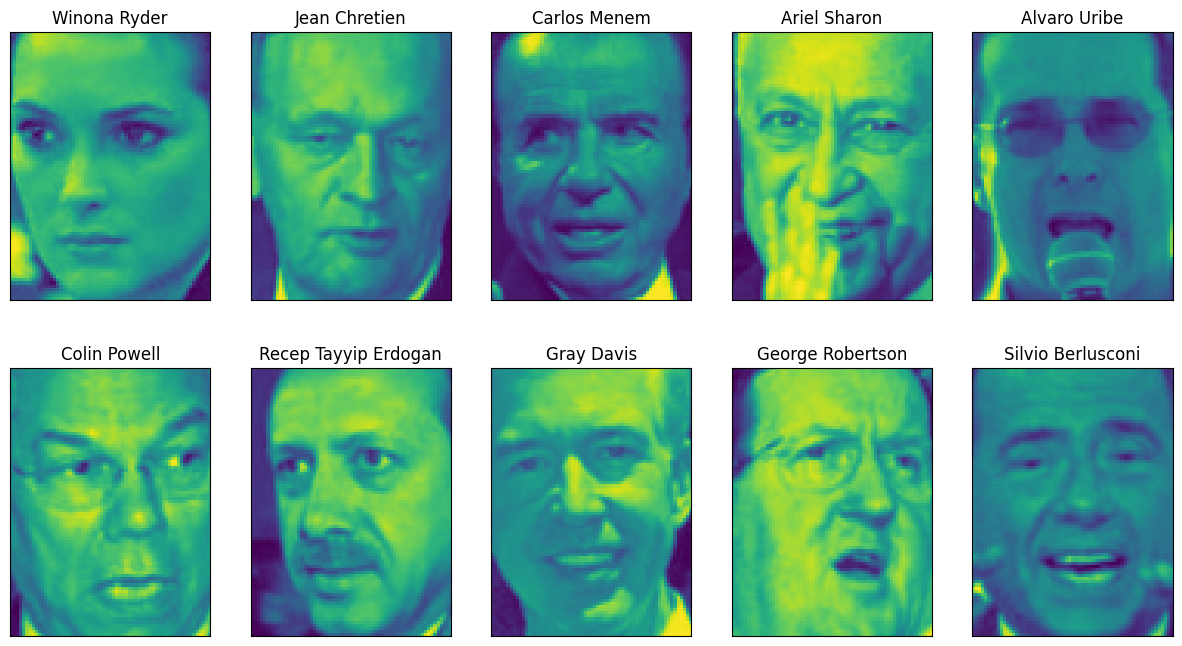

In [50]:
from sklearn.datasets import fetch_lfw_people

people = fetch_lfw_people(min_faces_per_person=20, resize = 0.7)

fix, axes = plt.subplots(2, 5, figsize = (15, 8), subplot_kw = {'xticks': (), 'yticks': ()})

for target, image, ax in zip(people.target, people.images, axes.ravel()):
    ax.imshow(image)
    ax.set_title(people.target_names[target])

In [51]:
print("People.image.shape: {}".format(people.images.shape))
print("Number of classes: {}".format(len(people.target_names)))

People.image.shape: (3023, 87, 65)
Number of classes: 62


In [52]:
counts = np.bincount(people.target)

for i, (count, name) in enumerate(zip(counts, people.target_names)):
    print('{0:25} {1:3}'.format(name, count))
    if((i+1) % 3 == 0):
        print()

Alejandro Toledo           39
Alvaro Uribe               35
Amelie Mauresmo            21

Andre Agassi               36
Angelina Jolie             20
Ariel Sharon               77

Arnold Schwarzenegger      42
Atal Bihari Vajpayee       24
Bill Clinton               29

Carlos Menem               21
Colin Powell              236
David Beckham              31

Donald Rumsfeld           121
George Robertson           22
George W Bush             530

Gerhard Schroeder         109
Gloria Macapagal Arroyo    44
Gray Davis                 26

Guillermo Coria            30
Hamid Karzai               22
Hans Blix                  39

Hugo Chavez                71
Igor Ivanov                20
Jack Straw                 28

Jacques Chirac             52
Jean Chretien              55
Jennifer Aniston           21

Jennifer Capriati          42
Jennifer Lopez             21
Jeremy Greenstock          24

Jiang Zemin                20
John Ashcroft              53
John Negroponte            31


In [53]:
mask = np.zeros(people.target.shape, dtype=np.bool)

for target in np.unique(people.target):
    mask[np.where(people.target==target)[0][:50]] = 1

X_people = people.data[mask]
y_people = people.target[mask]

#Grayscale
X_people = X_people/255

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_people, y_people, stratify=y_people, random_state=0)

In [55]:
pca = PCA(n_components = 100, whiten=True, random_state=0).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

print("X_train_pca.shape: {}".format(X_train_pca.shape))

X_train_pca.shape: (1547, 100)


### Non-Negative Matrix Factorization (NMF)

Non-negative matrix factorization is another unsupervised learning algorithm that
aims to extract useful features. It works similarly to PCA and can also be used for
dimensionality reduction

The process of decomposing data into a non-negative weighted sum is particularly
helpful for data that is created as the addition (or overlay) of several independent
sources, such as an audio track of multiple people speaking, or music with many
instruments. In these situations, NMF can identify the original components that
make up the combined data. Overall, NMF leads to more interpretable components
than PCA, as negative components and coefficients can lead to hard-to-interpret can‐
cellation effects. 

In contrast to when using PCA, we need to ensure that our data is positive for NMF
to be able to operate on the data. This means where the data lies relative to the origin
(0, 0) actually matters for NMF. Therefore, you can think of the non-negative compo‐
nents that are extracted as directions from (0, 0) toward the data.

### Manifold Learning with t-SNE


While PCA is often a good first approach for transforming your data so that you
might be able to visualize it using a scatter plot, the nature of the method (applying a
rotation and then dropping directions) limits its usefulness, as we saw with the scatter
plot of the Labeled Faces in the Wild dataset. There is a class of algorithms for visualization called manifold learning algorithms that allow for much more complex mappings, and often provide better visualizations. A particularly useful one is the t-SNE algorithm.

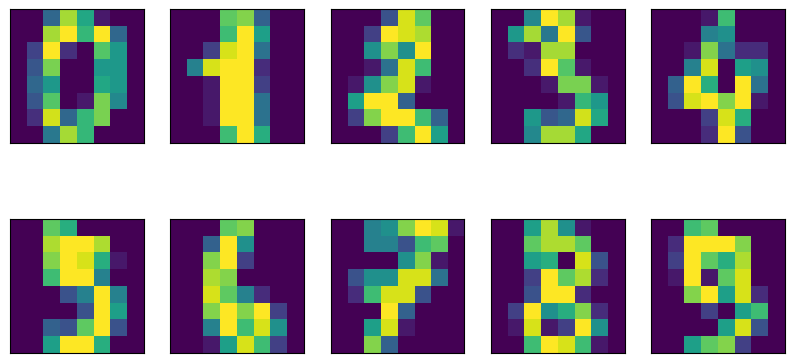

In [56]:
from sklearn.datasets import load_digits

digits = load_digits()

fig, axes = plt.subplots(2, 5, figsize=(10, 5), subplot_kw = {'xticks': (), 'yticks': ()})

for ax, img in zip(axes.ravel(),digits.images):
    ax.imshow(img)

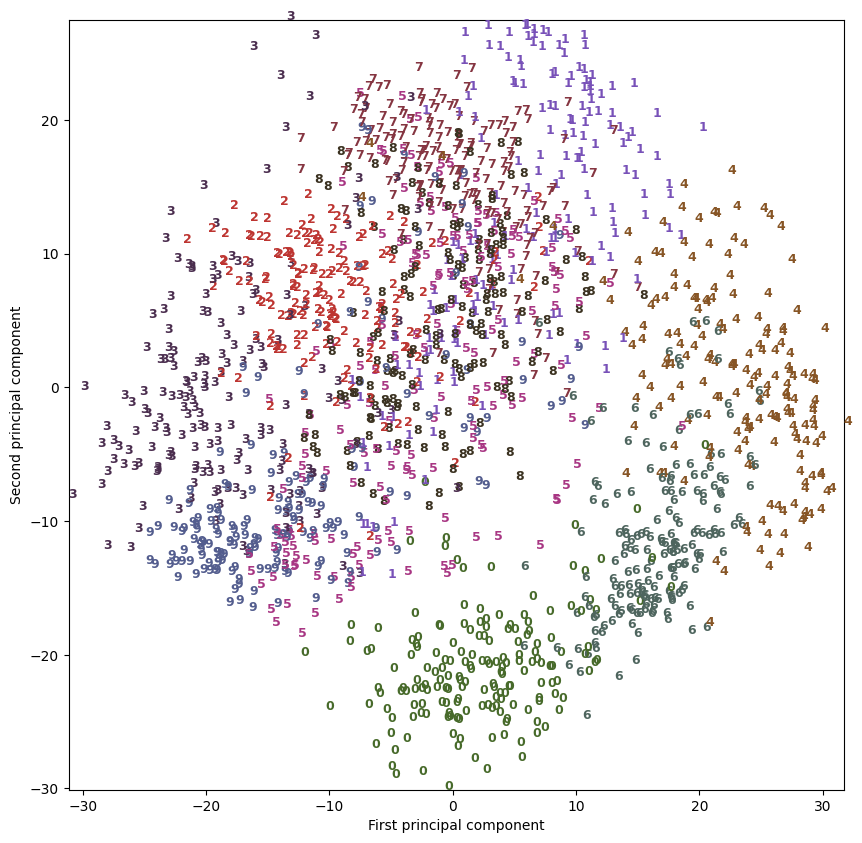

In [57]:
# build a PCA model
pca = PCA(n_components=2)
pca.fit(digits.data)
# transform the digits data onto the first two principal components
digits_pca = pca.transform(digits.data)
colors = ["#476A2A", "#7851B8", "#BD3430", "#4A2D4E", "#875525",
"#A83683", "#4E655E", "#853541", "#3A3120", "#535D8E"]
plt.figure(figsize=(10, 10))
plt.xlim(digits_pca[:, 0].min(), digits_pca[:, 0].max())
plt.ylim(digits_pca[:, 1].min(), digits_pca[:, 1].max())
for i in range(len(digits.data)):
    # actually plot the digits as text instead of using scatter
    plt.text(digits_pca[i, 0], digits_pca[i, 1], str(digits.target[i]),
    color = colors[digits.target[i]],
    fontdict={'weight': 'bold', 'size': 9})
    plt.xlabel("First principal component")
    plt.ylabel("Second principal component")

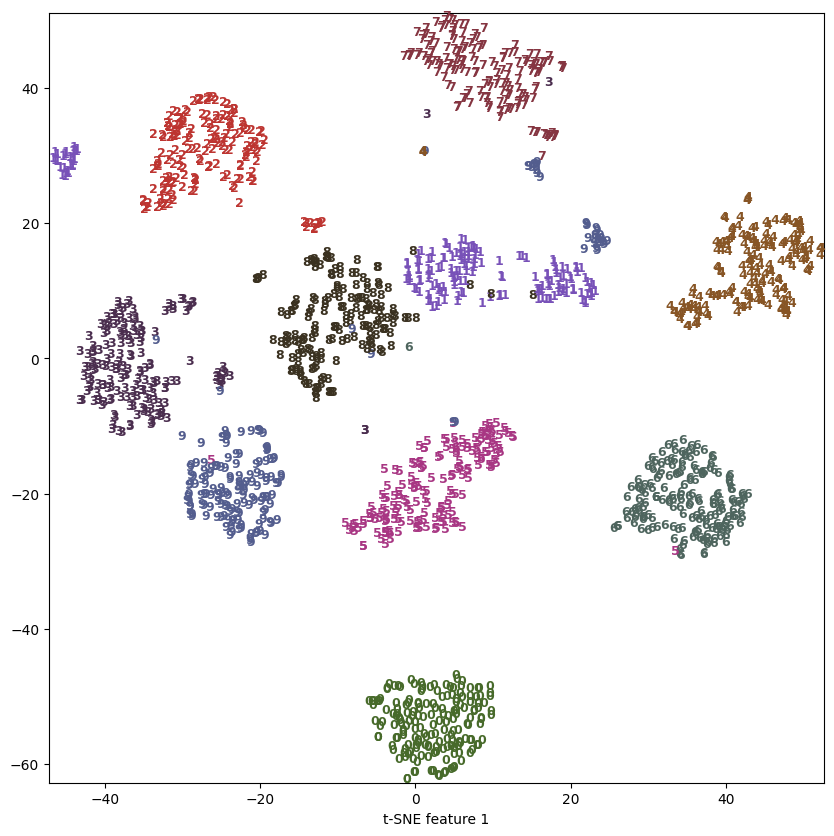

In [58]:
from sklearn.manifold import TSNE

tsne = TSNE(random_state=42)

digits_tsne = tsne.fit_transform(digits.data)
plt.figure(figsize=(10, 10))
plt.xlim(digits_tsne[:, 0].min(), digits_tsne[:, 0].max() + 1)
plt.ylim(digits_tsne[:, 1].min(), digits_tsne[:, 1].max() + 1)
for i in range(len(digits.data)):
    # actually plot the digits as text instead of using scatter
    plt.text(digits_tsne[i, 0], digits_tsne[i, 1], str(digits.target[i]),
    color = colors[digits.target[i]],
    fontdict={'weight': 'bold', 'size': 9})
    plt.xlabel("t-SNE feature 0")
    plt.xlabel("t-SNE feature 1")

### CLUSTERING
As we described earlier, clustering is the task of partitioning the dataset into groups,
called clusters. The goal is to split up the data in such a way that points within a single
cluster are very similar and points in different clusters are different. Similarly to clas‐
sification algorithms, clustering algorithms assign (or predict) a number to each data
point, indicating which cluster a particular point belongs to.

#### K-Means clustering
k-means clustering is one of the simplest and most commonly used clustering algo‐
rithms. It tries to find cluster centers that are representative of certain regions of the
data. The algorithm alternates between two steps: assigning each data point to the
closest cluster center, and then setting each cluster center as the mean of the data
points that are assigned to it. The algorithm is finished when the assignment of
instances to clusters no longer changes. 

In [59]:
from sklearn.cluster import KMeans

One of the drawbacks of k-means is that it relies on a random initialization, which
means the outcome of the algorithm depends on a random seed. By default, scikitlearn runs the algorithm 10 times with 10 different random initializations, and
returns the best result.4 Further downsides of k-means are the relatively restrictive
assumptions made on the shape of clusters, and the requirement to specify the num‐
ber of clusters you are looking for (which might not be known in a real-world
application).

#### Agglomerative Clustering
Agglomerative clustering refers to a collection of clustering algorithms that all build
upon the same principles: the algorithm starts by declaring each point its own cluster,
and then merges the two most similar clusters until some stopping criterion is satis‐
fied. The stopping criterion implemented in scikit-learn is the number of clusters,
so similar clusters are merged until only the specified number of clusters are left.
There are several linkage criteria that specify how exactly the “most similar cluster” is
measured. This measure is always defined between two existing clusters.

The following three choices are implemented in scikit-learn:
ward
The default choice, ward picks the two clusters to merge such that the variance
within all clusters increases the least. This often leads to clusters that are rela‐
tively equally sized.
average
average linkage merges the two clusters that have the smallest average distance
between all their points.
complete
complete linkage (also known as maximum linkage) merges the two clusters that
have the smallest maximum distance between their points.

#### DBSCAN
Another very useful clustering algorithm is DBSCAN (which stands for “density based spatial clustering of applications with noise”). The main benefits of DBSCAN
are that it does not require the user to set the number of clusters a priori, it can cap‐
ture clusters of complex shapes, and it can identify points that are not part of any
cluster. DBSCAN is somewhat slower than agglomerative clustering and k-means, but
still scales to relatively large datasets.
DBSCAN works by identifying points that are in “crowded” regions of the feature
space, where many data points are close together. These regions are referred to as
dense regions in feature space. The idea behind DBSCAN is that clusters form dense
regions of data, separated by regions that are relatively empty.

The algorithm works by picking an arbitrary point to start with. It then finds all
points with distance eps or less from that point. If there are less than min_samples
points within distance eps of the starting point, this point is labeled as noise, meaning
that it doesn’t belong to any cluster. If there are more than min_samples points within
a distance of eps, the point is labeled a core sample and assigned a new cluster label.
Then, all neighbors (within eps) of the point are visited. If they have not been
assigned a cluster yet, they are assigned the new cluster label that was just created. If
they are core samples, their neighbors are visited in turn, and so on. The cluster
grows until there are no more core samples within distance eps of the cluster. Then
another point that hasn’t yet been visited is picked, and the same procedure is
repeated.

#### Comparing and Evaluating Clustering Algorithms
One of the challenges in applying clustering algorithms is that it is very hard to assess
how well an algorithm worked, and to compare outcomes between different algo‐
rithms. After talking about the algorithms behind k-means, agglomerative clustering,
and DBSCAN, we will now compare them on some real-world datasets.

##### Evaluating clustering with ground truth
There are metrics that can be used to assess the outcome of a clustering algorithm
relative to a ground truth clustering, the most important ones being the adjusted rand
index (ARI) and normalized mutual information (NMI), which both provide a quanti‐
tative measure between 0 and 1.
A common mistake when evaluating clustering in this way is to use accuracy_score
instead of adjusted_rand_score, normalized_mutual_info_score, or some other
clustering metric. The problem in using accuracy is that it requires the assigned clus‐
ter labels to exactly match the ground truth. 

In [60]:
from sklearn.cluster import DBSCAN

In [61]:
dbscan = DBSCAN()
labels = dbscan.fit_predict(X_pca)
print("Accuracy score: {}".format(np.unique(labels)))

Accuracy score: [-1  0  1  2  3  4  5  6]


In [62]:
for eps in [1,3,5,7,9.11,13]:
    print("\neps={}".format(eps))
    dbscan = DBSCAN(eps=eps, min_samples=3)
    labels = dbscan.fit_predict(X_pca)
    print("Clusters present: {}".format(np.unique(labels)))
    print("Samples per clusters: {}".format(np.bincount(labels+1)))


eps=1
Clusters present: [-1  0  1  2  3]
Samples per clusters: [ 33 525   5   3   3]

eps=3
Clusters present: [-1  0]
Samples per clusters: [  2 567]

eps=5
Clusters present: [0]
Samples per clusters: [  0 569]

eps=7
Clusters present: [0]
Samples per clusters: [  0 569]

eps=9.11
Clusters present: [0]
Samples per clusters: [  0 569]

eps=13
Clusters present: [0]
Samples per clusters: [  0 569]


What is interesting to note is that there is never more than one large cluster. At most,
there is one large cluster containing most of the points, and some smaller clusters.
This indicates that there are not two or three different kinds of face images in the data
that are very distinct, but rather that all images are more or less equally similar to (or
dissimilar from) the rest.

## REPRESENTATING DATAS AND FEATURE ENGINEERING

### Categorical Variables


By far the most common way to represent categorical variables is using the one-hotencoding or one-out-of-N encoding, also known as dummy variables. The idea behind
dummy variables is to replace a categorical variable with one or more new features
that can have the values 0 and 1. The values 0 and 1 make sense in the formula for
linear binary classification (and for all other models in scikit-learn), and we can
represent any number of categories by introducing one new feature per category, as
described here

The one-hot encoding we use is quite similar, but not identical, to
the dummy encoding used in statistics. For simplicity, we encode
each category with a different binary feature. In statistics, it is com‐
mon to encode a categorical feature with k different possible values
into k–1 features (the last one is represented as all zeros). This is
done to simplify the analysis (more technically, this will avoid mak‐
ing the data matrix rank-deficient).

Categorical features are often encoded using integers. That they are
numbers doesn’t mean that they should necessarily be treated as
continuous features. It is not always clear whether an integer fea‐
ture should be treated as continuous or discrete (and one-hotencoded). If there is no ordering between the semantics that are
encoded (like in the workclass example), the feature must be
treated as discrete. For other cases, like five-star ratings, the better
encoding depends on the particular task and data and which
machine learning algorithm is used

### Binning, Discretization, Linear Models, and Trees


The best way to represent data depends not only on the semantics of the data, but also
on the kind of model you are using. Linear models and tree-based models (such as
decision trees, gradient boosted trees, and random forests), two large and very com‐
monly used families, have very different properties when it comes to how they work
with different feature representations. 

In [63]:
from sklearn.preprocessing import PolynomialFeatures

boston = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(boston.data, boston.target, random_state=0)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly = PolynomialFeatures(degree=2).fit(X_train_scaled)
X_train_poly = poly.transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print("Train dataset shape: {}".format(X_train_poly.shape))
print("Test dataset shape: {}".format(X_test_poly.shape))

Train dataset shape: (15480, 45)
Test dataset shape: (5160, 45)


In [64]:
ridge = Ridge().fit(X_train_scaled, y_train)
print("Score without interactions: {:.3f}".format(ridge.score(X_test_scaled, y_test)))
ridge = Ridge().fit(X_train_poly, y_train)
print("Score with interactions: {:.3f}".format(ridge.score(X_test_poly, y_test)))

Score without interactions: 0.584
Score with interactions: 0.605


In [65]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100).fit(X_train_scaled, y_train)
print("Score without interactions: {:.3f}".format(
rf.score(X_test_scaled, y_test)))
rf = RandomForestRegressor(n_estimators=100).fit(X_train_poly, y_train)
print("Score with interactions: {:.3f}".format(rf.score(X_test_poly, y_test)))

Score without interactions: 0.795
Score with interactions: 0.809


### Univariate Nonlinear Transformations


### Automatic Feature Selection


With so many ways to create new features, you might get tempted to increase the
dimensionality of the data way beyond the number of original features. However,
adding more features makes all models more complex, and so increases the chance of
overfitting. When adding new features, or with high-dimensional datasets in general,
it can be a good idea to reduce the number of features to only the most useful ones,
and discard the rest. This can lead to simpler models that generalize better. But how
can you know how good each feature is? There are three basic strategies: univariate
statistics, model-based selection, and iterative selection. We will discuss all three of
them in detail. All of these methods are supervised methods, meaning they need the
target for fitting the model. This means we need to split the data into training and test
sets, and fit the feature selection only on the training part of the data.

#### Univariate Statistics


In univariate statistics, we compute whether there is a statistically significant relation‐
ship between each feature and the target. Then the features that are related with the
highest confidence are selected. In the case of classification, this is also known as
analysis of variance (ANOVA). A key property of these tests is that they are univari‐
ate, meaning that they only consider each feature individually. Consequently, a fea‐
ture will be discarded if it is only informative when combined with another feature.
Univariate tests are often very fast to compute, and don’t require building a model.
On the other hand, they are completely independent of the model that you might
want to apply after the feature selection.

In [66]:
from sklearn.feature_selection import SelectPercentile, SelectFromModel

#get deterministic random numbers
rng =np.random.RandomState(42)
noise = rng.normal(size = (len(cancer.data), 50))
X_w_noise = np.hstack([cancer.data, noise])

X_train, X_test, y_train, y_test = train_test_split(X_w_noise, cancer.target, random_state=0, test_size=0.5)
select = SelectPercentile(percentile=50)
select.fit(X_train, y_train)

X_train_selected = select.transform(X_train)

print('X_train shape: {}'.format(X_train.shape))
print('X_train_selected shape: {}'.format(X_train_selected.shape))

X_train shape: (284, 80)
X_train_selected shape: (284, 40)


[ True  True  True  True  True  True  True  True  True False  True False
  True  True  True  True  True  True False False  True  True  True  True
  True  True  True  True  True  True False False False  True False  True
 False False  True False False False False  True False False  True False
 False  True False  True False False False False False False  True False
  True False False False False  True False  True False False False False
  True  True False  True False False False False]


Text(0.5, 0, 'Simple index')

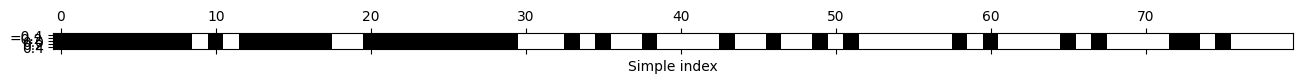

In [67]:
mask = select.get_support()
print(mask)

plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel('Simple index')

In [68]:
X_test_selected = select.transform(X_test)
lr = LogisticRegression()
lr.fit(X_train, y_train)
print("Score with all features: {:.3f}".format(lr.score(X_test, y_test)))
lr.fit(X_train_selected, y_train)
print("Score with only selected features: {:.3f}".format(lr.score(X_test_selected, y_test)))

Score with all features: 0.919
Score with only selected features: 0.919


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-le

#### Model-Based Feature Selection


Model-based feature selection uses a supervised machine learning model to judge the
importance of each feature, and keeps only the most important ones. The supervised
model that is used for feature selection doesn’t need to be the same model that is used
for the final supervised modeling. The feature selection model needs to provide some
measure of importance for each feature, so that they can be ranked by this measure

In [69]:
select = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold = 'median')
select.fit(X_train, y_train)
X_train_l1 = select.transform(X_train)
print('X_train shape: {}'.format(X_train.shape))
print('X_train_l1 shape: {}'.format(X_train_l1.shape))

X_train shape: (284, 80)
X_train_l1 shape: (284, 40)


In [70]:
X_test_l1 = select.transform(X_test)
print('Test score: {:.3f}'.format(lr.fit(X_train_l1, y_train).score(X_test_l1, y_test)))

Test score: 0.930


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Iterative Feature Selection

In univariate testing we used no model, while in model-based selection we used a sin‐
gle model to select features. In iterative feature selection, a series of models are built,
with varying numbers of features. There are two basic methods: starting with no fea‐
tures and adding features one by one until some stopping criterion is reached, or
starting with all features and removing features one by one until some stopping crite‐
rion is reached. Because a series of models are built, these methods are much more
computationally expensive than the methods we discussed previously. One particular
method of this kind is recursive feature elimination (RFE), which starts with all fea‐
tures, builds a model, and discards the least important feature according to the
model. Then a new model is built using all but the discarded feature, and so on until
only a prespecified number of features are left. For this to work, the model used for
selection needs to provide some way to determine feature importance, as was the case
for the model-based selection.

Text(0.5, 0, 'Sample index')

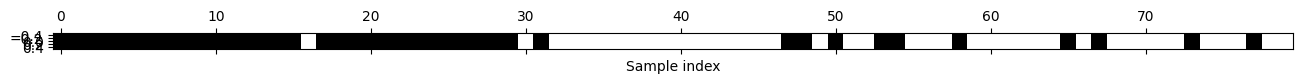

In [71]:
from sklearn.feature_selection import RFE
select = RFE(RandomForestClassifier(n_estimators=100, random_state=42),
n_features_to_select=40)
select.fit(X_train, y_train)
# visualize the selected features:
mask = select.get_support()
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")

In [72]:
X_train_rfe= select.transform(X_train)
X_test_rfe= select.transform(X_test)
score = LogisticRegression().fit(X_train_rfe, y_train).score(X_test_rfe, y_test)
print("Test score: {:.3f}".format(score))

Test score: 0.930


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Utilizing Expert Knowledge


Feature engineering is often an important place to use expert knowledge for a particu‐
lar application. While the purpose of machine learning in many cases is to avoid hav‐
ing to create a set of expert-designed rules, that doesn’t mean that prior knowledge of
the application or domain should be discarded. Often, domain experts can help in
identifying useful features that are much more informative than the initial represen‐
tation of the data. Imagine you work for a travel agency and want to predict flight
prices. Let’s say you have a record of prices together with dates, airlines, start loca‐
tions, and destinations. A machine learning model might be able to build a decent
model from that. Some important factors in flight prices, however, cannot be learned.
For example, flights are usually more expensive during peak vacation months and
around holidays. While the dates of some holidays (like Christmas) are fixed, and
their effect can therefore be learned from the date, others might depend on the phases
of the moon (like Hanukkah and Easter) or be set by authorities (like school holi‐
days). These events cannot be learned from the data if each flight is only recorded
using the (Gregorian) date. However, it is easy to add a feature that encodes whether a
flight was on, preceding, or following a public or school holiday. In this way, prior
knowledge about the nature of the task can be encoded in the features to aid a
machine learning algorithm. Adding a feature does not force a machine learning
algorithm to use it, and even if the holiday information turns out to be noninforma‐
tive for flight prices, augmenting the data with this information doesn’t hurt.

## Model Evaluation and Improvement


### Cross-Validation


Cross-validation is a statistical method of evaluating generalization performance that
is more stable and thorough than using a split into a training and a test set. In crossvalidation, the data is instead split repeatedly and multiple models are trained. The
most commonly used version of cross-validation is k-fold cross-validation, where k is
a user-specified number, usually 5 or 10. When performing five-fold cross-validation,
the data is first partitioned into five parts of (approximately) equal size, called folds.
Next, a sequence of models is trained. The first model is trained using the first fold as
the test set, and the remaining folds (2–5) are used as the training set. The model is
built using the data in folds 2–5, and then the accuracy is evaluated on fold 1. Then
another model is built, this time using fold 2 as the test set and the data in folds 1, 3,
4, and 5 as the training set. This process is repeated using folds 3, 4, and 5 as test sets.
For each of these five splits of the data into training and test sets, we compute the
accuracy. 

In [73]:
from sklearn.model_selection import cross_val_score

iris= load_iris()
logreg = LogisticRegression()

scores = cross_val_score(logreg, iris.data, iris.target)
print("Cross-validation scores: {}".format(scores))

Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [74]:
scores = cross_val_score(logreg, iris.data, iris.target, cv=4) #By default, cross_val_score returns an array of 5 values
print("Cross-validation scores: {}".format(scores))

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Cross-validation scores: [0.97368421 0.97368421 0.94594595 1.        ]


A common way to summarize the cross-validation accuracy is to compute the mean:


#### Benefits of Cross-Validation


There are several benefits to using cross-validation instead of a single split into a
training and a test set. First, remember that train_test_split performs a random
split of the data. Imagine that we are “lucky” when randomly splitting the data, and
all examples that are hard to classify end up in the training set. In that case, the test
set will only contain “easy” examples, and our test set accuracy will be unrealistically
high. Conversely, if we are “unlucky,” we might have randomly put all the hard-toclassify examples in the test set and consequently obtain an unrealistically low score.
However, when using cross-validation, each example will be in the training set exactly
once: each example is in one of the folds, and each fold is the test set once. Therefore,
the model needs to generalize well to all of the samples in the dataset for all of the
cross-validation scores (and their mean) to be high.
Having multiple splits of the data also provides some information about how sensi‐
tive our model is to the selection of the training dataset. For the iris dataset, we saw
accuracies between 90% and 100%. This is quite a range, and it provides us with an
idea about how the model might perform in the worst case and best case scenarios
when applied to new data.
Another benefit of cross-validation as compared to using a single split of the data is
that we use our data more effectively. When using train_test_split, we usually use
75% of the data for training and 25% of the data for evaluation. When using five-fold
cross-validation, in each iteration we can use four-fifths of the data (80%) to fit the
model. When using 10-fold cross-validation, we can use nine-tenths of the data
(90%) to fit the model. More data will usually result in more accurate models.
The main disadvantage of cross-validation is increased computational cost. As we are
now training k models instead of a single model, cross-validation will be roughly k
times slower than doing a single split of the data.

It is important to keep in mind that cross-validation is not a way to
build a model that can be applied to new data. Cross-validation
does not return a model. When calling cross_val_score, multiple
models are built internally, but the purpose of cross-validation is
only to evaluate how well a given algorithm will generalize when
trained on a specific dataset.

#### Stratified k-Fold Cross-Validation and Other Strategies


In [75]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits=5)

print("Cross-validation scores:\n{}".format(cross_val_score(logreg, iris.data, iris.target, cv=kfold)))

Cross-validation scores:
[1.         1.         0.86666667 0.93333333 0.83333333]


In [76]:
kfold = KFold(n_splits=3, shuffle=True, random_state=0)
print("Cross-validation scores:\n{}".format(cross_val_score(logreg, iris.data, iris.target, cv=kfold)))

Cross-validation scores:
[0.98 0.96 0.96]


In [77]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()
scores = cross_val_score(logreg, iris.data, iris.target, cv=loo)
print("Number of cv iterations: ", len(scores))
print("Mean accuracy: {:.2f}".format(scores.mean()))

C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-le

Number of cv iterations:  150
Mean accuracy: 0.97


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
from sklearn.model_selection import ShuffleSplit
shuffle_split = ShuffleSplit(test_size=.5, train_size=.5, n_splits=10)
scores = cross_val_score(logreg, iris.data, iris.target, cv=shuffle_split)
print("Cross-validation scores:\n{}".format(scores))

Cross-validation scores:
[0.98666667 0.96       0.96       0.98666667 0.94666667 0.93333333
 0.98666667 0.90666667 0.96       0.96      ]


### Grid Search

Now that we know how to evaluate how well a model generalizes, we can take the
next step and improve the model’s generalization performance by tuning its parame‐
ters. We discussed the parameter settings of many of the algorithms in scikit-learn
in Chapters 2 and 3, and it is important to understand what the parameters mean
before trying to adjust them. Finding the values of the important parameters of a
model (the ones that provide the best generalization performance) is a tricky task, but
necessary for almost all models and datasets. Because it is such a common task, there
are standard methods in scikit-learn to help you with it. The most commonly used
method is grid search, which basically means trying all possible combinations of the
parameters of interest

In [79]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target)
print("Training set: {} and test set: {}".format(X_train.shape[0], X_test.shape[0]))
best_score=0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in  [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_test, y_test)

        if score > best_score:
            best_score=score
            best_params = {'C': C, "gamma": gamma}

print("Best score: {}".format(score))
print("Best parameters: {}".format(best_params))
        

Training set: 112 and test set: 38
Best score: 0.3157894736842105
Best parameters: {'C': 100, 'gamma': 0.001}


Given this result, we might be tempted to report that we found a model that performs
with 97% accuracy on our dataset. However, this claim could be overly optimistic (or
just wrong), for the following reason: we tried many different parameters and selected the one with best accuracy on the test set, but this accuracy won’t necessarily
carry over to new data. Because we used the test data to adjust the parameters, we can
no longer use it to assess how good the model is. This is the same reason we needed
to split the data into training and test sets in the first place; we need an independent
dataset to evaluate, one that was not used to create the model.

In [80]:
X_train_val, X_test, y_train_val, y_test = train_test_split(iris.data, iris.target, random_state=0)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_val, y_train_val, random_state=1)

print("Training set: {}, Validation set: {} and test set: {}".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))
best_score=0

for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in  [0.001, 0.01, 0.1, 1, 10, 100]:
        svm = SVC(gamma=gamma, C=C)
        svm.fit(X_train, y_train)
        score = svm.score(X_valid, y_valid)

        if score > best_score:
            best_score=score
            best_params = {'C': C, "gamma": gamma}

print("Best score: {}".format(score))
print("Best parameters: {}".format(best_params))

svm = SVC(**best_params)
svm.fit(X_train_val, y_train_val)
score = svm.score(X_test, y_test)
print("Test score with the best parameters : {}".format(score))        

Training set: 84, Validation set: 28 and test set: 38
Best score: 0.6428571428571429
Best parameters: {'C': 10, 'gamma': 0.001}
Test score with the best parameters : 0.9210526315789473


### Grid Search with Cross-Validation


While the method of splitting the data into a training, a validation, and a test set that
we just saw is workable, and relatively commonly used, it is quite sensitive to how
exactly the data is split. From the output of the previous code snippet we can see that
GridSearchCV selects 'C': 10, 'gamma': 0.001 as the best parameters, while the
output of the code in the previous section selects 'C': 100, 'gamma': 0.001 as the
best parameters. For a better estimate of the generalization performance, instead of
using a single split into a training and a validation set, we can use cross-validation to
evaluate the performance of each parameter combination. 

In [81]:
for gamma in [0.001, 0.01, 0.1, 1, 10, 100]:
    for C in [0.001, 0.01, 0.1, 1, 10, 100]:
        # for each combination of parameters,
        # train an SVC
        svm = SVC(gamma=gamma, C=C)
        # perform cross-validation
        scores = cross_val_score(svm, X_train_val, y_train_val, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_parameters = {'C': C, 'gamma': gamma}
        
# rebuild a model on the combined training and validation set
svm = SVC(**best_parameters)
svm.fit(X_train_val, y_train_val)

print("Best score: {}".format(score))
print("Best parameters: {}".format(best_params))
score = svm.score(X_test, y_test)
print("Test score with the best parameters : {}".format(score))  

Best score: 0.5814229249011857
Best parameters: {'C': 10, 'gamma': 0.001}
Test score with the best parameters : 0.9736842105263158


In [82]:
from sklearn.model_selection import GridSearchCV

params_grid = {"gamma":[0.001, 0.01, 0.1, 1, 10, 100], "C": [0.001, 0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(SVC(), params_grid, cv=5)

X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

grid_search.fit(X_train, y_train)

print("Test score: {:.2f}".format(grid_search.score(X_test, y_test)))

Test score: 0.97


Fitting the GridSearchCV object not only searches for the best parameters, but also
automatically fits a new model on the whole training dataset with the parameters that
yielded the best cross-validation performance. The
GridSearchCV class provides a very convenient interface to access the retrained
model using the predict and score methods.

In [83]:
print("Best parameters: {}".format(grid_search.best_params_))
print("Best cross-validation score: {}".format(grid_search.best_score_))

Best parameters: {'C': 10, 'gamma': 0.1}
Best cross-validation score: 0.9731225296442687


Again, be careful not to confuse best_score_ with the generaliza‐
tion performance of the model as computed by the score method
on the test set. Using the score method (or evaluating the output of
the predict method) employs a model trained on the whole train‐
ing set. The best_score_ attribute stores the mean cross-validation
accuracy, with cross-validation performed on the training set.

Sometimes it is helpful to have access to the actual model that was found—for exam‐
ple, to look at coefficients or feature importances. You can access the model with the
best parameters trained on the whole training set using the best_estimator_
attribute

In [84]:
print("Best estimator: {}".format(grid_search.best_estimator_))

Best estimator: SVC(C=10, gamma=0.1)


In [85]:
results = pd.DataFrame(grid_search.cv_results_)
print(results)

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  param_C  \
0        0.001306  6.059359e-04         0.001202        0.000751    0.001   
1        0.001214  2.617084e-04         0.000806        0.000368    0.001   
2        0.000903  1.948364e-04         0.001002        0.000004    0.001   
3        0.001116  2.312907e-04         0.000800        0.000400    0.001   
4        0.000902  1.943832e-04         0.001003        0.000005    0.001   
5        0.001116  2.331258e-04         0.000988        0.000024    0.001   
6        0.001000  6.843901e-07         0.000703        0.000399    0.010   
7        0.000988  2.354340e-05         0.000916        0.000510    0.010   
8        0.001103  2.047117e-04         0.000915        0.000510    0.010   
9        0.001280  8.854365e-04         0.000916        0.000510    0.010   
10       0.001327  5.949836e-04         0.000600        0.000491    0.010   
11       0.001342  2.363003e-04         0.000898        0.000257    0.010   

### Evaluation Metrics and Scoring


#### Keep the End Goal in Mind


When selecting a metric, you should always have the end goal of the machine learn‐
ing application in mind. In practice, we are usually interested not just in making
accurate predictions, but in using these predictions as part of a larger decisionmaking process. Before picking a machine learning metric, you should think about
the high-level goal of the application, often called the business metric. The conse‐
quences of choosing a particular algorithm for a machine learning application are called the business impact.2 Maybe the high-level goal is avoiding traffic accidents, or
decreasing the number of hospital admissions. It could also be getting more users for
your website, or having users spend more money in your shop. When choosing a
model or adjusting parameters, you should pick the model or parameter values that
have the most positive influence on the business metric. Often this is hard, as assess‐
ing the business impact of a particular model might require putting it in production
in a real-life system.

In the early stages of development, and for adjusting parameters, it is often infeasible
to put models into production just for testing purposes, because of the high business
or personal risks that can be involved. Imagine evaluating the pedestrian avoidance
capabilities of a self-driving car by just letting it drive around, without verifying it
first; if your model is bad, pedestrians will be in trouble! Therefore we often need to
find some surrogate evaluation procedure, using an evaluation metric that is easier to
compute. For example, we could test classifying images of pedestrians against nonpedestrians and measure accuracy. Keep in mind that this is only a surrogate, and it
pays off to find the closest metric to the original business goal that is feasible to evalu‐
ate. This closest metric should be used whenever possible for model evaluation and
selection. The result of this evaluation might not be a single number—the conse‐
quence of your algorithm could be that you have 10% more customers, but each cus‐
tomer will spend 15% less—but it should capture the expected business impact of
choosing one model over another.

#### Metrics for binary classification

Relation to accuracy. We already saw one way to summarize the result in the confu‐
sion matrix—by computing accuracy, which can be expressed as:
Accuracy = TP+TN/(TP+TN + FP + FN)
In other words, accuracy is the number of correct predictions (TP and TN) divided
by the number of all samples (all entries of the confusion matrix summed up).
Precision, recall, and f-score. There are several other ways to summarize the confusion
matrix, with the most common ones being precision and recall. Precision measures
how many of the samples predicted as positive are actually positive:
Precision = TP/(TP+FP)
Precision is used as a performance metric when the goal is to limit the number of
false positives. As an example, imagine a model for predicting whether a new drug
will be effective in treating a disease in clinical trials. Clinical trials are notoriously
expensive, and a pharmaceutical company will only want to run an experiment if it is
very sure that the drug will actually work. Therefore, it is important that the model
does not produce many false positives—in other words, that it has a high precision.
Precision is also known as positive predictive value (PPV).
Recall, on the other hand, measures how many of the positive samples are captured
by the positive predictions:
Recall = TP/(TP+FN)
Recall is used as performance metric when we need to identify all positive samples;
that is, when it is important to avoid false negatives. The cancer diagnosis example
from earlier in this chapter is a good example for this: it is important to find all peo‐
ple that are sick, possibly including healthy patients in the prediction. Other names
for recall are sensitivity, hit rate, or true positive rate (TPR).
There is a trade-off between optimizing recall and optimizing precision. You can triv‐
ially obtain a perfect recall if you predict all samples to belong to the positive class—
there will be no false negatives, and no true negatives either. However, predicting all
samples as positive will result in many false positives, and therefore the precision will
be very low. On the other hand, if you find a model that predicts only the single data
point it is most sure about as positive and the rest as negative, then precision will be
perfect (assuming this data point is in fact positive), but recall will be very bad.

Precision and recall are only two of many classification measures
derived from TP, FP, TN, and FN. You can find a great summary of
all the measures on Wikipedia. In the machine learning commu‐
nity, precision and recall are arguably the most commonly used
measures for binary classification, but other communities might
use other related metrics.
So, while precision and recall are very important measures, looking at only one of
them will not provide you with the full picture. One way to summarize them is the
f-score or f-measure, which is with the harmonic mean of precision and recall:
F = 2 · precision·recall/(precision+recall)


#### Metrics for Multiclass Classification


Apart from
accuracy, common tools are the confusion matrix and the classification report we saw. 

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=0)
lr = LogisticRegression().fit(X_train, y_train)
pred = lr.predict(X_test)

print("Accuracy: {:.3f}".format(accuracy_score(y_test, y_test)))
print("Confusion matrix: {}".format(confusion_matrix(y_test, pred)))

Accuracy: 1.000
Confusion matrix: [[37  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  2  1]
 [ 0  1 40  3  0  0  0  0  0  0]
 [ 0  0  0 43  0  0  0  0  1  1]
 [ 0  0  0  0 37  0  0  1  0  0]
 [ 0  0  0  0  0 46  0  0  0  2]
 [ 0  1  0  0  0  0 51  0  0  0]
 [ 0  0  0  1  1  0  0 46  0  0]
 [ 0  3  1  0  0  0  0  0 43  1]
 [ 0  0  0  0  0  1  0  0  1 45]]


C:\Users\KRYPTONIUM\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


The most commonly used metric for imbalanced datasets in the multiclass setting is
the multiclass version of the f-score. The idea behind the multiclass f-score is to com‐
pute one binary f-score per class, with that class being the positive class and the other
classes making up the negative classes. Then, these per-class f-scores are averaged
using one of the following strategies:
• "macro" averaging computes the unweighted per-class f-scores. This gives equal
weight to all classes, no matter what their size is.
• "weighted" averaging computes the mean of the per-class f-scores, weighted by
their support. This is what is reported in the classification report.
• "micro" averaging computes the total number of false positives, false negatives,
and true positives over all classes, and then computes precision, recall, and fscore using these counts.

In [87]:
print("Micro average f1 score: {:.3f}".format(f1_score(y_test, pred, average="micro")))
print("Macro average f1 score: {:.3f}".format(f1_score(y_test, pred, average="macro")))

Micro average f1 score: 0.951
Macro average f1 score: 0.952


#### Regression Metrics


Evaluation for regression can be done in similar detail as we did for classification—
for example, by analyzing overpredicting the target versus underpredicting the target.
However, in most applications we’ve seen, using the default R2 used in the score
method of all regressors is enough. Sometimes business decisions are made on the
basis of mean squared error or mean absolute error, which might give incentive to
tune models using these metrics. In general, though, we have found R2 to be a more
intuitive metric to evaluate regression models.

#### Using Evaluation Metrics in Model Selection


We have discussed many evaluation methods in detail, and how to apply them given
the ground truth and a model. However, we often want to use metrics like AUC in
model selection using GridSearchCV or cross_val_score. Luckily scikit-learn
provides a very simple way to achieve this, via the scoring argument that can be used
in both GridSearchCV and cross_val_score. You can simply provide a string
describing the evaluation metric you want to use. 

In [88]:
print("Default scoring: {}".format(cross_val_score(SVC(), digits.data, digits.target == 9)))
# providing scoring="accuracy" doesn't change the results
explicit_accuracy = cross_val_score(SVC(), digits.data, digits.target == 9, scoring="accuracy")
print("Explicit accuracy scoring: {}".format(explicit_accuracy))
roc_auc = cross_val_score(SVC(), digits.data, digits.target == 9, scoring="roc_auc")
print("AUC scoring: {}".format(roc_auc))

Default scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
Explicit accuracy scoring: [0.975      0.99166667 1.         0.99442897 0.98050139]
AUC scoring: [0.99717078 0.99854252 1.         0.999828   0.98400413]


## ALGORITHM CHAINS AND PIPELINES

For many machine learning algorithms, the particular representation of the data that
you provide is very important. This starts with scaling
the data and combining features by hand and goes all the way to learning features
using unsupervised machine learning. Consequently, most
machine learning applications require not only the application of a single algorithm,
but the chaining together of many different processing steps and machine learning
models. 

In [89]:
X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, random_state=0)

### Parameter Selection with Preprocessing


So, the splits in the cross-validation no longer correctly mirror how new data will
look to the modeling process. We already leaked information from these parts of the
data into our modeling process. This will lead to overly optimistic results during
cross-validation, and possibly the selection of suboptimal parameters.
To get around this problem, the splitting of the dataset during cross-validation should
be done before doing any preprocessing. Any process that extracts knowledge from the
dataset should only ever be applied to the training portion of the dataset, so any
cross-validation should be the “outermost loop” in your processing.
To achieve this in scikit-learn with the cross_val_score function and the Grid
SearchCV function, we can use the Pipeline class. The Pipeline class is a class that
allows “gluing” together multiple processing steps into a single scikit-learn estimatorr. The Pipeline class itself has fit, predict, and score methods and behaves just
like any other model in scikit-learn. The most common use case of the Pipeline
class is in chaining preprocessing steps (like scaling of the data) together with a
supervised model like a classifier. 

### Building Pipelines


In [90]:
from sklearn.pipeline import Pipeline, make_pipeline
pipe = Pipeline([("Scaler", MinMaxScaler()), ("svm", SVC())])

In [91]:
pipe.fit(X_train, y_train)
print("Accuracy score: {}".format(pipe.score(X_test, y_test)))

Accuracy score: 0.972027972027972


Using the pipeline, we reduced the
code needed for our “preprocessing + classification” process. The main benefit of
using the pipeline, however, is that we can now use this single estimator in
cross_val_score or GridSearchCV.

### Using Pipelines in Grid Searches


Using a pipeline in a grid search works the same way as using any other estimator. We
define a parameter grid to search over, and construct a GridSearchCV from the pipe‐
line and the parameter grid. When specifying the parameter grid, there is a slight
change, though. We need to specify for each parameter which step of the pipeline it
belongs to. Both parameters that we want to adjust, C and gamma, are parameters of
SVC, the second step. We gave this step the name "svm". The syntax to define a param‐
eter grid for a pipeline is to specify for each parameter the step name, followed by __
(a double underscore), followed by the parameter name. To search over the C param‐
eter of SVC we therefore have to use "svm__C" as the key in the parameter grid dictio‐
nary, and similarly for gamma.

In [92]:
params_grid = {'svm__C': [0.001, 0.01, 0.1, 1, 10, 100], 'svm__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, params_grid, cv=5)
grid.fit(X_train, y_train)
print("Best cross-validation accuracy: {:.2f}".format(grid.best_score_))
print("Test score: {:.2f}".format(grid.score(X_test, y_test)))
print("Best parameters: {}".format(grid.best_params_))
                                  

Best cross-validation accuracy: 0.98
Test score: 0.97
Best parameters: {'svm__C': 1, 'svm__gamma': 1}


The impact of leaking information in the cross-validation varies depending on the
nature of the preprocessing step. Estimating the scale of the data using the test fold
usually doesn’t have a terrible impact, while using the test fold in feature extraction
and feature selection can lead to substantial differences in outcomes.

### The General Pipeline Interface


The Pipeline class is not restricted to preprocessing and classification, but can in
fact join any number of estimators together. For example, you could build a pipeline
containing feature extraction, feature selection, scaling, and classification, for a total
of four steps. Similarly, the last step could be regression or clustering instead of classi‐
fication.
The only requirement for estimators in a pipeline is that all but the last step need to
have a transform method, so they can produce a new representation of the data that
can be used in the next step.
Internally, during the call to Pipeline.fit, the pipeline calls fit and then transform
on each step in turn,2 with the input given by the output of the transform method of
the previous step. For the last step in the pipeline, just fit is called.

#### Convenient Pipeline Creation with make_pipeline

Creating a pipeline using the syntax described earlier is sometimes a bit cumbersome,
and we often don’t need user-specified names for each step. There is a convenience
function, make_pipeline, that will create a pipeline for us and automatically name
each step based on its class. 

In [93]:
pipe_short = make_pipeline(MinMaxScaler(), SVC(C=100))
pipe_long = Pipeline([("scaler", MinMaxScaler()), ("svm", SVC(C=100))])

print("pipe_short steps: {}".format(pipe_long.steps))
print("pipe_short steps: {}".format(pipe_short.steps))

pipe_short steps: [('scaler', MinMaxScaler()), ('svm', SVC(C=100))]
pipe_short steps: [('minmaxscaler', MinMaxScaler()), ('svc', SVC(C=100))]


In [94]:
pipe = make_pipeline(StandardScaler(), PCA(n_components=2), StandardScaler())
print("Pipeline stesp: {}".format(pipe.steps))

Pipeline stesp: [('standardscaler-1', StandardScaler()), ('pca', PCA(n_components=2)), ('standardscaler-2', StandardScaler())]


#### Accessing Step Attributes


Often you will want to inspect attributes of one of the steps of the pipeline—say, the
coefficients of a linear model or the components extracted by PCA. The easiest way to
access the steps in a pipeline is via the named_steps attribute, which is a dictionary
from the step names to the estimators

In [95]:
# fit the pipeline defined before to the cancer dataset
pipe.fit(cancer.data)
# extract the first two principal components from the "pca" step
components = pipe.named_steps["pca"].components_
print("components.shape: {}".format(components.shape))

components.shape: (2, 30)


#### Accessing Attributes in a Grid-Searched Pipeline


A common task is to access some of the steps of a pipeline inside
a grid search. Let’s grid search a LogisticRegression classifier on the cancer dataset,
using Pipeline and StandardScaler to scale the data before passing it to the Logisti
cRegression classifier.

In [96]:
pipe = make_pipeline(StandardScaler(), LogisticRegression())

param_grid = {"logisticregression__C": [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression())]),
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100]})

In [97]:
print("Grid best estimator: {}".format(grid.best_estimator_))

Grid best estimator: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(C=1))])


In [98]:
print("Logistic regression steps: {}".format(grid.best_estimator_.named_steps["logisticregression"]))

Logistic regression steps: LogisticRegression(C=1)


#### Grid-Searching Preprocessing Steps and Model Parameters

Using pipelines, we can encapsulate all the processing steps in our machine learning
workflow in a single scikit-learn estimator. Another benefit of doing this is that we
can now adjust the parameters of the preprocessing using the outcome of a supervised
task like regression or classification. 

In [99]:
X_train, X_test, y_train, y_test = train_test_split(california.data, california.target, random_state=0)

pipe = make_pipeline(StandardScaler(), PolynomialFeatures(), Ridge())

param_grid = {'polynomialfeatures__degree': [1, 2, 3], "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

grid = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('polynomialfeatures',
                                        PolynomialFeatures()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'polynomialfeatures__degree': [1, 2, 3],
                         'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100]})

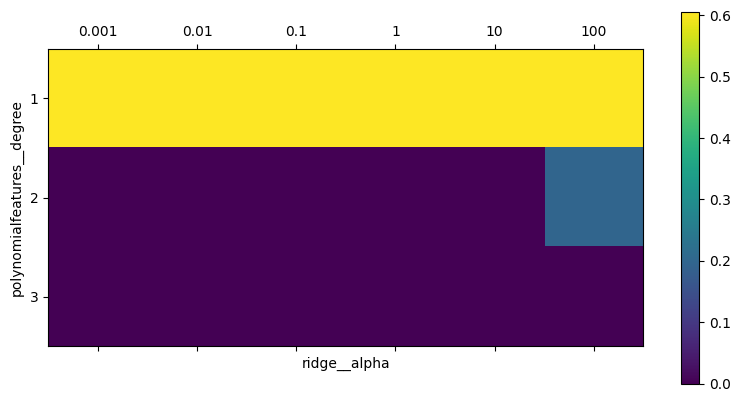

In [100]:
plt.matshow(grid.cv_results_['mean_test_score'].reshape(3, -1),
vmin=0, cmap="viridis")
plt.xlabel("ridge__alpha")
plt.ylabel("polynomialfeatures__degree")
plt.xticks(range(len(param_grid['ridge__alpha'])), param_grid['ridge__alpha'])
plt.yticks(range(len(param_grid['polynomialfeatures__degree'])),
param_grid['polynomialfeatures__degree'])
plt.colorbar()

In [101]:
print("Best parameters: {}".format(grid.best_params_))

Best parameters: {'polynomialfeatures__degree': 1, 'ridge__alpha': 10}


In [102]:
print("Test score: {:.2f}".format(grid.score(X_test, y_test)))

Test score: 0.59


### Grid-Searching Which Model To Use


You can even go further in combining GridSearchCV and Pipeline: it is also possible
to search over the actual steps being performed in the pipeline (say whether to use
StandardScaler or MinMaxScaler). This leads to an even bigger search space and
should be considered carefully. Trying all possible solutions is usually not a viable
machine learning strategy. However, here is an example comparing a RandomForest
Classifier and an SVC on the iris dataset. We know that the SVC might need the
data to be scaled, so we also search over whether to use StandardScaler or no pre‐
processing. For the RandomForestClassifier, we know that no preprocessing is necessary. 

In [103]:
pipe = Pipeline([("preprocessing", StandardScaler()), ("classifier", SVC())])

param_grid = [{'classifier': [SVC()], 'preprocessing': [StandardScaler(), None], 'classifier__gamma': [0.001, 0.01, 0.1, 1, 10, 100]}, {'classifier': [RandomForestClassifier(n_estimators=100)], 'preprocessing': [None], 'classifier__max_features': [1, 2, 3]}]

In [104]:
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=0)

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best params: {}".format(grid.best_params_))
print("Best cross-validation score: {}".format(grid.best_score_))
print("Test accuracy: {}".format(grid.score(X_test, y_test)))

Best params: {'classifier': SVC(), 'classifier__gamma': 0.1, 'preprocessing': None}
Best cross-validation score: 0.9640316205533598
Test accuracy: 0.9736842105263158


In this chapter we introduced the Pipeline class, a general-purpose tool to chain
together multiple processing steps in a machine learning workflow. Real-world appli‐
cations of machine learning rarely involve an isolated use of a model, and instead are
a sequence of processing steps. Using pipelines allows us to encapsulate multiple steps
into a single Python object that adheres to the familiar scikit-learn interface of fit,
predict, and transform. In particular when doing model evaluation using crossvalidation and parameter selection using grid search, using the Pipeline class to cap‐
ture all the processing steps is essential for proper evaluation. The Pipeline class also
allows writing more succinct code, and reduces the likelihood of mistakes that can
happen when building processing chains without the pipeline class (like forgetting
to apply all transformers on the test set, or not applying them in the right order).
Choosing the right combination of feature extraction, preprocessing, and models is
somewhat of an art, and often requires some trial and error. However, using pipe‐
lines, this “trying out” of many different processing steps is quite simple. When experimenting, be careful not to overcomplicate your processes, and make sure to
evaluate whether every component you are including in your model is necessary.
With this chapter, we have completed our survey of general-purpose tools and algo‐
rithms provided by scikit-learn. You now possess all the required skills and know
the necessary mechanisms to apply machine learning in practice. In the next chapter,
we will dive in more detail into one particular type of data that is commonly seen in
practice, and that requires some special expertise to handle correctly: text data.

## WORKING WITH TEXT DATA

### Types of Data Represented as Strings


There are four kinds of string data you might see:

• Categorical data

• Free strings that can be semantically mapped to categories

• Structured string data

• Text data

Categorical data is data that comes from a fixed list. Say you collect data via a survey
where you ask people their favorite color, with a drop-down menu that allows them
to select from “red,” “green,” “blue,” “yellow,” “black,” “white,” “purple,” and “pink.”
This will result in a dataset with exactly eight different possible values, which clearly
encode a categorical variable. You can check whether this is the case for your data by
eyeballing it (if you see very many different strings it is unlikely that this is a categori‐
cal variable) and confirm it by computing the unique values over the dataset, and
possibly a histogram over how often each appears. You also might want to check
whether each variable actually corresponds to a category that makes sense for your
application. Maybe halfway through the existence of your survey, someone found that
“black” was misspelled as “blak” and subsequently fixed the survey. As a result, your
dataset contains both “blak” and “black,” which correspond to the same semantic
meaning and should be consolidated.

The final category of string data is freeform text data that consists of phrases or sen‐
tences. Examples include tweets, chat logs, and hotel reviews, as well as the collected
works of Shakespeare, the content of Wikipedia, or the Project Gutenberg collection
of 50,000 ebooks. All of these collections contain information mostly as sentences
composed of words.1 For simplicity’s sake, let’s assume all our documents are in one
language, English.2 In the context of text analysis, the dataset is often called the cor‐
pus, and each data point, represented as a single text, is called a document. These
terms come from the information retrieval (IR) and natural language processing (NLP)
community, which both deal mostly in text data.

### Example Application: Sentiment Analysis of Movie Reviews

### Representing Text Data as a Bag of Words


One of the most simple but effective and commonly used ways to represent text for
machine learning is using the bag-of-words representation. When using this represen‐
tation, we discard most of the structure of the input text, like chapters, paragraphs,
sentences, and formatting, and only count how often each word appears in each text in the corpus. Discarding the structure and counting only word occurrences leads to the
mental image of representing text as a “bag.”
Computing the bag-of-words representation for a corpus of documents consists of
the following three steps:

1. Tokenization. Split each document into the words that appear in it (called tokens),
for example by splitting them on whitespace and punctuation.

2. Vocabulary building. Collect a vocabulary of all words that appear in any of the
documents, and number them (say, in alphabetical order).

3. Encoding. For each document, count how often each of the words in the vocabu‐
lary appear in this document.

#### Applying Bag-of-Words to a Toy Dataset


In [110]:
bards_words =["The fool doth think he is wise,",
"but the wise man knows himself to be a fool"]

In [118]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

vect = CountVectorizer()
vect.fit(bards_words)

print("Vocabulary size: {}".format(len(vect.vocabulary_)))
print("Vocabulary size: {}".format(vect.vocabulary_))

Vocabulary size: 13
Vocabulary size: {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [115]:
bag_of_words = vect.transform(bards_words)
print("Bag of words: {}".format(repr(bag_of_words)))

Bag of words: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 16 stored elements and shape (2, 13)>


The bag-of-words representation is stored in a SciPy sparse matrix that only stores
the entries that are nonzero (see Chapter 1). The matrix is of shape 2×13, with one
row for each of the two data points and one feature for each of the words in the
vocabulary. A sparse matrix is used as most documents only contain a small subset of
the words in the vocabulary, meaning most entries in the feature array are 0.

In [116]:
print("Dense representation of bag of words: {}".format(bag_of_words.toarray()))

Dense representation of bag of words: [[0 0 1 1 1 0 1 0 0 1 1 0 1]
 [1 1 0 1 0 1 0 1 1 1 0 1 1]]


#### Bag-of-Words for Movie Reviews


### Stopwords


Another way that we can get rid of uninformative words is by discarding words that
are too frequent to be informative. There are two main approaches: using a languagespecific list of stopwords, or discarding words that appear too frequently. scikitlearn has a built-in list of English stopwords in the feature_extraction.text
module.

In [121]:
print("Number of stop words: {}".format(len(ENGLISH_STOP_WORDS)))
print("Every 10th stop words: {}".format(list(ENGLISH_STOP_WORDS)[::10]))

Number of stop words: 318
Every 10th stop words: ['besides', 'can', 'could', 'nobody', 'been', 'some', 'con', 'through', 'last', 'yet', 'because', 'do', 'wherein', 'each', 'sometimes', 'forty', 'though', 'toward', 'eight', 'into', 'whether', 'somewhere', 'further', 'may', 'more', 'while', 'herein', 'becoming', 'whither', 'neither', 'hundred', 'sincere']


Clearly, removing the stopwords in the list can only decrease the number of features
by the length of the list—here, 318—but it might lead to an improvement in perfor‐
mance. 

### Rescaling the Data with tf–idf


Instead of dropping features that are deemed unimportant, another approach is to
rescale features by how informative we expect them to be. One of the most common
ways to do this is using the term frequency–inverse document frequency (tf–idf)
method. The intuition of this method is to give high weight to any term that appears
often in a particular document, but not in many documents in the corpus. If a word
appears often in a particular document, but not in very many documents, it is likely
to be very descriptive of the content of that document. scikit-learn implements the
tf–idf method in two classes: TfidfTransformer, which takes in the sparse matrix
output produced by CountVectorizer and transforms it, and TfidfVectorizer,
which takes in the text data and does both the bag-of-words feature extraction and
the tf–idf transformation. There are several variants of the tf–idf rescaling scheme,
which you can read about on Wikipedia. The tf–idf score for word w in document d
as implemented in both the TfidfTransformer and TfidfVectorizer classes is given
by:

tfidf(w, d) = tf log ((N + 1)/(Nw + 1))

where N is the number of documents in the training set, Nw is the number of docu‐
ments in the training set that the word w appears in, and tf (the term frequency) is the
number of times that the word w appears in the query document d (the document
you want to transform or encode). Both classes also apply L2 normalization after
computing the tf–idf representation; in other words, they rescale the representation
of each document to have Euclidean norm 1. Rescaling in this way means that the
length of a document (the number of words) does not change the vectorized repre‐
sentation.

### Investigating Model Coefficients


Finally, let’s look in a bit more detail into what our logistic regression model actually
learned from the data. Because there are so many features—27,271 after removing the
infrequent ones—we clearly cannot look at all of the coefficients at the same time.
However, we can look at the largest coefficients, and see which words these corre‐
spond to. We will use the last model that we trained, based on the tf–idf features.

### Bag-of-Words with More Than One Word (n-Grams)


One of the main disadvantages of using a bag-of-words representation is that word
order is completely discarded. Therefore, the two strings “it’s bad, not good at all” and
“it’s good, not bad at all” have exactly the same representation, even though the mean‐
ings are inverted. Putting “not” in front of a word is only one example (if an extreme
one) of how context matters. Fortunately, there is a way of capturing context when
using a bag-of-words representation, by not only considering the counts of single
tokens, but also the counts of pairs or triplets of tokens that appear next to each other.
Pairs of tokens are known as bigrams, triplets of tokens are known as trigrams, and
more generally sequences of tokens are known as n-grams. 

We can change the range
of tokens that are considered as features by changing the ngram_range parameter of
CountVectorizer or TfidfVectorizer. The ngram_range parameter is a tuple, consisting of the minimum length and the maximum length of the sequences of tokens
that are considered. Here is an example on the toy data we used earlier

In [123]:
cv = CountVectorizer(ngram_range=(1,1)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary: {}".format(cv.vocabulary_))

Vocabulary size: 13
Vocabulary: {'the': 9, 'fool': 3, 'doth': 2, 'think': 10, 'he': 4, 'is': 6, 'wise': 12, 'but': 1, 'man': 8, 'knows': 7, 'himself': 5, 'to': 11, 'be': 0}


In [129]:
cv = CountVectorizer(ngram_range=(2,2)).fit(bards_words)
print("Vocabulary size: {}".format(len(cv.vocabulary_)))
print("Vocabulary: {}".format(cv.vocabulary_))

Vocabulary size: 14
Vocabulary: {'the fool': 9, 'fool doth': 3, 'doth think': 2, 'think he': 11, 'he is': 4, 'is wise': 6, 'but the': 1, 'the wise': 10, 'wise man': 13, 'man knows': 8, 'knows himself': 7, 'himself to': 5, 'to be': 12, 'be fool': 0}


### Advanced Tokenization, Stemming, and Lemmatization


This problem can be overcome by representing each word using its word stem, which
involves identifying (or conflating) all the words that have the same word stem. If this
is done by using a rule-based heuristic, like dropping common suffixes, it is usually
referred to as stemming. If instead a dictionary of known word forms is used (an
explicit and human-verified system), and the role of the word in the sentence is taken
into account, the process is referred to as lemmatization and the standardized form of
the word is referred to as the lemma. Both processing methods, lemmatization and
stemming, are forms of normalization that try to extract some normal form of a
word. 

In [134]:
!pip install --upgrade pip

   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 985.5 kB/s eta 0:00:02
   ----------------- ---------------------- 0.8/1.8 MB 1.0 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.1 MB/s eta 0:00:01
   ----------------------------- ---------- 1.3/1.8 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.1 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Users\KRYPTONIUM\miniconda3\python.exe -m pip install --upgrade pip


### Topic Modeling and Document Clustering


Each of the components we
learn then corresponds to one topic, and the coefficients of the components in the
representation of a document tell us how strongly related that document is to a par‐
ticular topic. Often, when people talk about topic modeling, they refer to one particu‐
lar decomposition method called Latent Dirichlet Allocation (often LDA for short).

#### Latent Dirichlet Allocation


Intuitively, the LDA model tries to find groups of words (the topics) that appear
together frequently. LDA also requires that each document can be understood as a
“mixture” of a subset of the topics. It is important to understand that for the machine
learning model a “topic” might not be what we would normally call a topic in every‐
day speech, but that it resembles more the components extracted by PCA or NMF, which might or might not have a semantic mean‐
ing. Even if there is a semantic meaning for an LDA “topic”, it might not be some‐
thing we’d usually call a topic. Going back to the example of news articles, we might
have a collection of articles about sports, politics, and finance, written by two specific
authors. In a politics article, we might expect to see words like “governor,” “vote,”
“party,” etc., while in a sports article we might expect words like “team,” “score,” and
“season.” Words in each of these groups will likely appear together, while it’s less likely
that, for example, “team” and “governor” will appear together. However, these are not
the only groups of words we might expect to appear together. The two reporters
might prefer different phrases or different choices of words. Maybe one of them likes
to use the word “demarcate” and one likes the word “polarize.” Other “topics” would
then be “words often used by reporter A” and “words often used by reporter B,”
though these are not topics in the usual sense of the word.

## WRAPPING UP

### Approaching a Machine Learning Problem


. The machine learning algorithm is usually only a small part of a larger data
analysis and decision-making process. To make effective use of machine learning, we
need to take a step back and consider the problem at large. First, you should think
about what kind of question you want to answer. Do you want to do exploratory anal‐
ysis and just see if you find something interesting in the data? Or do you already have
a particular goal in mind? Often you will start with a goal, like detecting fraudulent
user transactions, making movie recommendations, or finding unknown planets. If
you have such a goal, before building a system to achieve it, you should first think
about how to define and measure success, and what the impact of a successful solu‐
tion would be to your overall business or research goals. Let’s say your goal is fraud
detection.

Then the following questions open up:

• How do I measure if my fraud prediction is actually working?

• Do I have the right data to evaluate an algorithm?

• If I am successful, what will be the business impact of my solution?

This is often hard to do, though. A question that can be easier to answer is “What if I
built the perfect model?” If perfectly detecting any fraud will save your company $100
a month, these possible savings will probably not be enough to warrant the effort of
you even starting to develop an algorithm. On the other hand, if the model might
save your company tens of thousands of dollars every month, the problem might be
worth exploring.
Say you’ve defined the problem to solve, you know a solution might have a significant
impact for your project, and you’ve ensured that you have the right information to
evaluate success. The next steps are usually acquiring the data and building a working
prototype. In this book we have talked about many models you can employ, and how
to properly evaluate and tune these models. While trying out models, though, keep in
mind that this is only a small part of a larger data science workflow, and model build‐
ing is often part of a feedback circle of collecting new data, cleaning data, building
models, and analyzing the models. Analyzing the mistakes a model makes can often
be informative about what is missing in the data, what additional data could be col‐
lected, or how the task could be reformulated to make machine learning more effec‐
tive. Collecting more or different data or changing the task formulation slightly might
provide a much higher payoff than running endless grid searches to tune parameters.

#### Humans in the Loop


You should also consider if and how you should have humans in the loop. Some pro‐
cesses (like pedestrian detection in a self-driving car) need to make immediate deci‐
sions. Others might not need immediate responses, and so it can be possible to have
humans confirm uncertain decisions. Medical applications, for example, might need
very high levels of precision that possibly cannot be achieved by a machine learning
algorithm alone. But if an algorithm can make 90 percent, 50 percent, or maybe even
just 10 percent of decisions automatically, that might already increase response time
or reduce cost. Many applications are dominated by “simple cases,” for which an algo‐
rithm can make a decision, with relatively few “complicated cases,” which can be
rerouted to a human.

### From Prototype to Production


Python and scikit-learn are
also used in production systems in many organizations—even very large ones like
international banks and global social media companies. However, many companies
have complex infrastructure, and it is not always easy to include Python in these sys‐
tems. That is not necessarily a problem. In many companies, the data analytics teams
work with languages like Python and R that allow the quick testing of ideas, while
production teams work with languages like Go, Scala, C++, and Java to build robust,
scalable systems. Data analysis has different requirements from building live services,
and so using different languages for these tasks makes sense. A relatively common
solution is to reimplement the solution that was found by the analytics team inside
the larger framework, using a high-performance language. This can be easier than
embedding a whole library or programming language and converting from and to the
different data formats.

### Testing Production Systems


The tools we’ve discussed in this book are great for many machine learning applica‐
tions, and allow very quick analysis and prototyping. Python and scikit-learn are
also used in production systems in many organizations—even very large ones like
international banks and global social media companies. However, many companies
have complex infrastructure, and it is not always easy to include Python in these sys‐
tems. That is not necessarily a problem. In many companies, the data analytics teams
work with languages like Python and R that allow the quick testing of ideas, while
production teams work with languages like Go, Scala, C++, and Java to build robust,
scalable systems. Data analysis has different requirements from building live services,
and so using different languages for these tasks makes sense. A relatively common
solution is to reimplement the solution that was found by the analytics team inside
the larger framework, using a high-performance language. This can be easier than
embedding a whole library or programming language and converting from and to the
different data formats.
Regardless of whether you can use scikit-learn in a production system or not, it is
important to keep in mind that production systems have different requirements from
one-off analysis scripts. If an algorithm is deployed into a larger system, software
engineering aspects like reliability, predictability, runtime, and memory requirements
gain relevance. Simplicity is key in providing machine learning systems that perform
well in these areas. Critically inspect each part of your data processing and prediction
pipeline and ask yourself how much complexity each step creates, how robust each
component is to changes in the data or compute infrastructure, and if the benefit of
each component warrants the complexity. If you are building involved machine learn‐
ing systems, we highly recommend reading the paper “Machine Learning: The High
Interest Credit Card of Technical Debt”, published by researchers in Google’s
machine learning team. The paper highlights the trade-off in creating and maintain‐
ing machine learning software in production at a large scale. While the issue of tech‐
nical debt is particularly pressing in large-scale and long-term projects, the lessons
learned can help us build better software even for short-lived and smaller systems.

### Testing Production Systems


If your machine
learning system is user-facing, this is only the first step in evaluating an algorithm,
though. The next step is usually online testing or live testing, where the consequences
of employing the algorithm in the overall system are evaluated. Changing the recom‐
mendations or search results users are shown by a website can drastically change
their behavior and lead to unexpected consequences. To protect against these sur‐
prises, most user-facing services employ A/B testing, a form of blind user study. In A/B testing, without their knowledge a selected portion of users will be provided with
a website or service using algorithm A, while the rest of the users will be provided
with algorithm B. For both groups, relevant success metrics will be recorded for a set
period of time. Then, the metrics of algorithm A and algorithm B will be compared,
and a selection between the two approaches will be made according to these metrics.
Using A/B testing enables us to evaluate the algorithms “in the wild,” which might
help us to discover unexpected consequences when users are interacting with our
model. Often A is a new model, while B is the established system. There are more
elaborate mechanisms for online testing that go beyond A/B testing, such as bandit
algorithms. A great introduction to this subject can be found in the book Bandit Algo‐
rithms for Website Optimization by John Myles White (O’Reilly).

### Building Your Own Estimator


how can you use your own processing together
with the scikit-learn tools? There is a simple solution: build your own estimator!
Implementing an estimator that is compatible with the scikit-learn interface, so
that it can be used with Pipeline, GridSearchCV, and cross_val_score, is quite easy.
You can find detailed instructions in the scikit-learn documentation, but here is
the gist. The simplest way to implement a transformer class is by inheriting from
BaseEstimator and TransformerMixin, and then implementing the __init__, fit,
and predict functions